# Proyecto Rappi: análisis de variables relevantes para predecir el tiempo de entrega

Este notebook ayuda a identificar qué columnas aportan valor real para predecir el tiempo de entrega, limpiar variables innecesarias y visualizar las relaciones más importantes antes de entrenar un modelo.

Objetivo principal: estimar el tiempo de entrega en minutos utilizando factores observables antes del envío, sin incluir columnas con fuga de información ni identificadores que solo sirven como claves.

In [40]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import kagglehub
from kagglehub import KaggleDatasetAdapter

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [41]:
file_path = 'Food_Delivery_Time_Prediction.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
else:
    df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        'dharmendrapandit12/food-delivery-time-prediction-dataset',
        file_path,
    )

print(f'Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas')
df.columns = [str(c).strip() for c in df.columns]
display(df.head(5))
display(df.dtypes.to_frame(name='tipo'))

Dimensiones: 50,000 filas x 24 columnas


,Order_ID,Order_Date,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,Rider_Experience_Years,Rider_Rating,Restaurant_Rating,Cuisine_Type,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
0,ORD000001,2025-10-28,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,3.10,3.80,3.80,Pizza,1,Medium,23,30.55,Long,Moderate,15,28.70,Normal,91
1,ORD000002,2025-09-26,12,Friday,0,0,Rain,CBD,CBD,Scooter,1.80,3.60,3.90,Desserts,3,Medium,11,2.25,Short,Moderate,17,23.30,Normal,21
2,ORD000003,2025-01-26,18,Sunday,1,0,Clear,Residential,Residential,Scooter,3.80,3.90,4.00,Biryani,1,Low,31,10.15,Long,Moderate,8,28.90,Normal,52
3,ORD000004,2025-11-19,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,1.70,3.90,4.60,Burger,3,Medium,19,26.33,Long,Low,9,41.40,Normal,59
4,ORD000005,2025-08-04,18,Monday,0,0,Rain,Industrial,Residential,Bike,12.40,4.40,4.00,Desserts,1,Medium,7,30.48,Long,Moderate,8,31.70,Normal,75


,tipo
Order_ID,str
Order_Date,str
Order_Hour,int64
Day_of_Week,str
Is_Weekend,int64
Is_Festival,int64
Weather,str
Pickup_Zone,str
Dropoff_Zone,str
Vehicle_Type,str


## 1. Revisión de columnas relevantes y limpieza inicial

Antes de entrenar cualquier modelo, se deben separar tres tipos de variables:

- Variables objetivo: tiempo de entrega en minutos.
- Variables operativas: distancia, tráfico, clima, zona, condiciones del repartidor, tipo de pedido.
- Variables no útiles o de fuga: IDs, nombres, referencias internas, detalles que no aportan información real para predecir el tiempo a futuro.

La estrategia aquí es detectar columnas por nombre, tipo y relación con la variable objetivo, en lugar de asumir que todas las columnas son útiles.

In [42]:
# --- Helpers de detección ---
def find_column(keywords, default=None):
    if isinstance(keywords, str):
        keywords = [keywords]
    for c in df.columns:
        low = c.lower()
        if all(k.lower() in low for k in keywords):
            return c
    return default

# Objetivo principal: tiempo de entrega
candidate_targets = [
    'time_taken', 'delivery_time', 'delivery_time_min', 'time_taken_min',
    'delivery duration', 'delivery_time_minutes', 'total_time'
]
time_col = None
for key in candidate_targets:
    time_col = find_column(key)
    if time_col is not None:
        break

if time_col is None:
    raise ValueError('No se encontró una columna objetivo de tiempo. Revisa el nombre exacto del CSV.')

df['target_time'] = pd.to_numeric(df[time_col], errors='coerce')
print('Columna objetivo encontrada:', time_col)
print('Resumen objetivo:')
print(df['target_time'].describe())

# Variables operativas relevantes por nombre
traffic_col = find_column(['traffic', 'road_traffic', 'traffic_density'])
weather_col = find_column(['weather', 'climate'])
city_col = find_column(['city'])
festival_col = find_column(['festival'])
vehicle_col = find_column(['vehicle', 'vehicle_condition'])
order_type_col = find_column(['type_of_order', 'order_type'])
restaurant_lat = find_column(['restaurant', 'rest', 'lat'], 'latitude')
restaurant_lon = find_column(['restaurant', 'rest', 'lon'], 'longitude')

# Cálculo de distancia aproximada en km si existen coordenadas
lat_cols = [c for c in df.columns if 'latitude' in c.lower()]
lon_cols = [c for c in df.columns if 'longitude' in c.lower()]

if len(lat_cols) >= 2 and len(lon_cols) >= 2:
    lat1, lat2 = lat_cols[0], lat_cols[1]
    lon1, lon2 = lon_cols[0], lon_cols[1]
    R = 6371.0
    lat1_rad = np.radians(df[lat1].astype(float))
    lat2_rad = np.radians(df[lat2].astype(float))
    dlat = np.radians(df[lat2].astype(float) - df[lat1].astype(float))
    dlon = np.radians(df[lon2].astype(float) - df[lon1].astype(float))
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2) ** 2
    df['distance_km'] = 2 * R * np.arcsin(np.sqrt(a))
    print('Se calculó distance_km usando coordenadas del restaurante y destino.')

# Columnas inútiles a filtrar para el modelo
redundant_patterns = [
    'id', 'name', 'address', 'mobile', 'phone', 'email', 'order_id',
    'driver_id', 'restaurant_id', 'delivery_person_id', 'customer_id'
]

columns_to_drop = []
for c in df.columns:
    low = c.lower()
    if c == time_col or c == 'target_time':
        continue
    if any(p in low for p in redundant_patterns):
        columns_to_drop.append(c)

columns_to_drop = list(dict.fromkeys(columns_to_drop))
print('Columnas descartadas por ser identificadores o irrelevantes:', columns_to_drop[:10])

# Variables de interés para el análisis y el modelo
relevant_columns = [
    c for c in df.columns
    if c not in columns_to_drop and c not in [time_col, 'target_time']
]

print('\nVariables potencialmente relevantes:')
for c in relevant_columns[:30]:
    print('-', c)

# Perfil de calidad de columnas
profile = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'faltantes': df.isna().sum(),
    '%_faltantes': round(df.isna().mean() * 100, 2),
    'valores_unicos': df.nunique(dropna=True)
}).sort_values(['faltantes', 'valores_unicos'], ascending=[False, True])

display(profile.head(25))

Columna objetivo encontrada: Time_taken_min
Resumen objetivo:
count   50000.00
mean       83.87
std        35.43
min        10.00
25%        58.00
50%        78.00
75%       102.00
max       180.00
Name: target_time, dtype: float64
Columnas descartadas por ser identificadores o irrelevantes: ['Order_ID', 'Rider_Experience_Years', 'Rider_Rating']

Variables potencialmente relevantes:
- Order_Date
- Order_Hour
- Day_of_Week
- Is_Weekend
- Is_Festival
- Weather
- Pickup_Zone
- Dropoff_Zone
- Vehicle_Type
- Restaurant_Rating
- Cuisine_Type
- Order_Items
- Restaurant_Load
- Preparation_Time_Min
- Road_Distance_km
- Delivery_Distance_Category
- Traffic_Level
- Number_of_Signals
- Average_Speed_kmph
- Delivery_Priority


,tipo,faltantes,%_faltantes,valores_unicos
Is_Weekend,int64,0,0.00,2
Is_Festival,int64,0,0.00,2
Restaurant_Load,str,0,0.00,3
Delivery_Distance_Category,str,0,0.00,3
Delivery_Priority,str,0,0.00,3
Vehicle_Type,str,0,0.00,4
Traffic_Level,str,0,0.00,4
Weather,str,0,0.00,5
Pickup_Zone,str,0,0.00,5
Dropoff_Zone,str,0,0.00,5


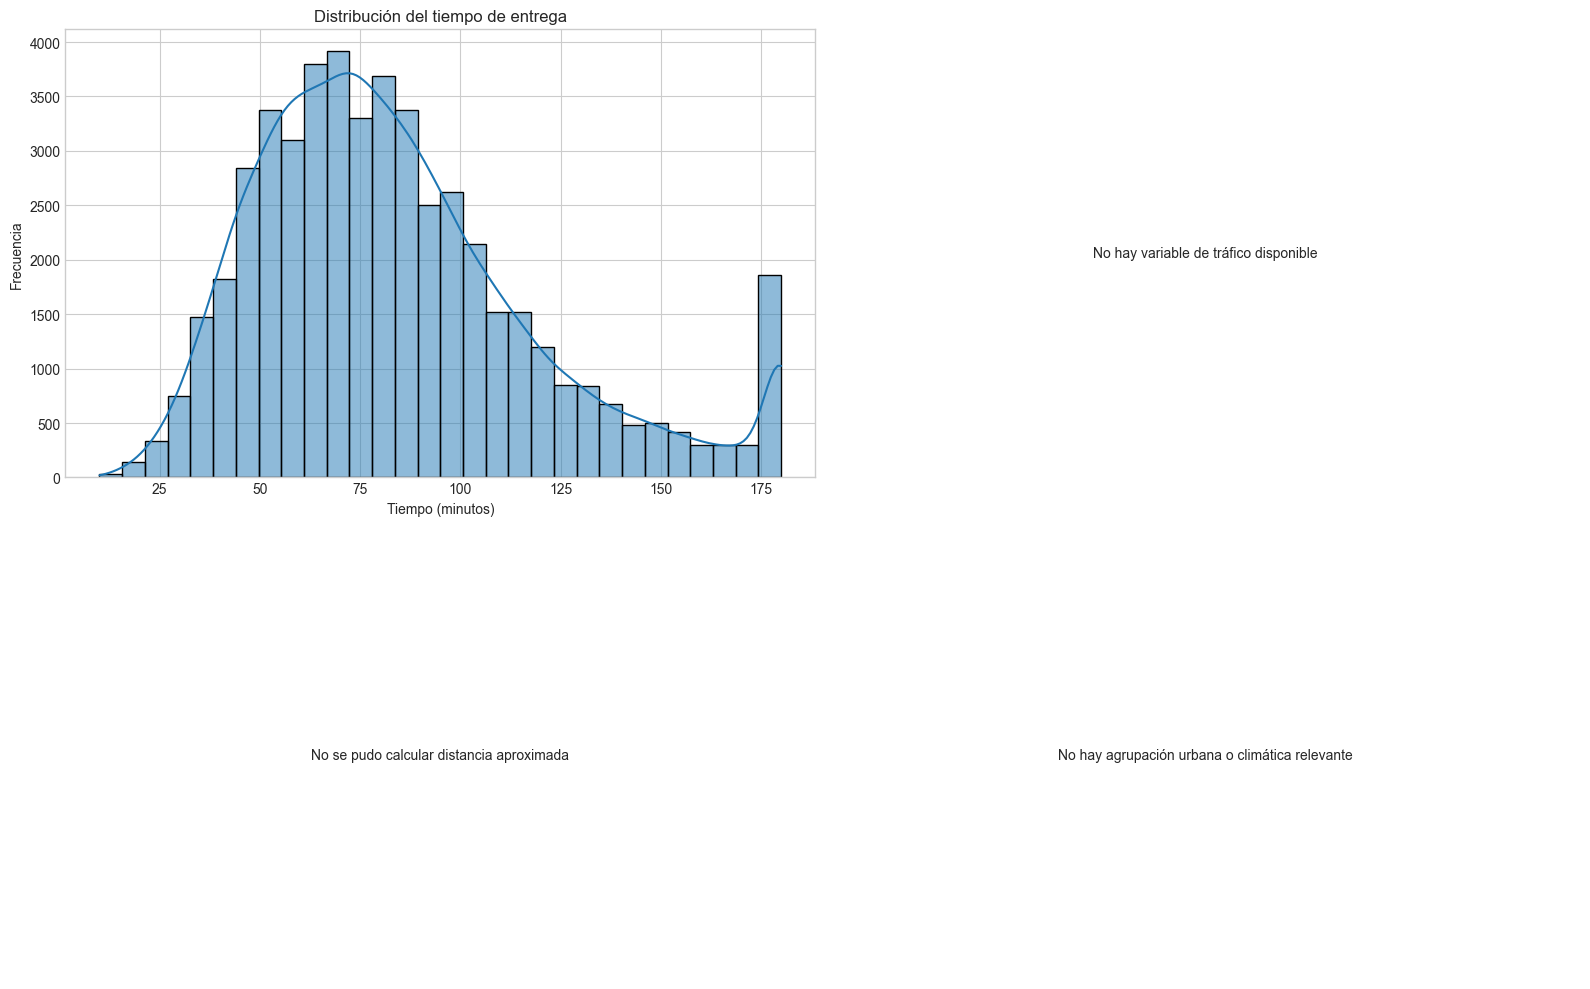

In [43]:
# --- Gráficos 1 a 4: análisis visual de la variable objetivo y relaciones clave ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Histograma del tiempo de entrega
sns.histplot(df['target_time'].dropna(), bins=30, kde=True, color='#1f77b4', ax=axes[0, 0])
axes[0, 0].set_title('Distribución del tiempo de entrega')
axes[0, 0].set_xlabel('Tiempo (minutos)')
axes[0, 0].set_ylabel('Frecuencia')

# 2. Boxplot por tráfico si existe
if traffic_col:
    order = ['Low', 'Medium', 'High', 'Very High'] if any(x.lower() in str(df[traffic_col].dropna().unique()).lower() for x in ['low', 'medium', 'high', 'very high']) else None
    sns.boxplot(data=df, x=traffic_col, y='target_time', order=order, palette='viridis', ax=axes[0, 1])
    axes[0, 1].set_title('Tiempo de entrega por nivel de tráfico')
    axes[0, 1].set_xlabel('Tráfico')
    axes[0, 1].set_ylabel('Tiempo (minutos)')
else:
    axes[0, 1].text(0.5, 0.5, 'No hay variable de tráfico disponible', ha='center', va='center', transform=axes[0, 1].transAxes)
    axes[0, 1].set_axis_off()

# 3. Relación distancia - tiempo si existe
if 'distance_km' in df.columns:
    sns.scatterplot(data=df, x='distance_km', y='target_time', alpha=0.55, color='#d62728', ax=axes[1, 0])
    axes[1, 0].set_title('Distancia aproximada vs tiempo de entrega')
    axes[1, 0].set_xlabel('Distancia (km)')
    axes[1, 0].set_ylabel('Tiempo (minutos)')
else:
    axes[1, 0].text(0.5, 0.5, 'No se pudo calcular distancia aproximada', ha='center', va='center', transform=axes[1, 0].transAxes)
    axes[1, 0].set_axis_off()

# 4. Promedio por ciudad o clima si existe
if city_col:
    city_summary = df.groupby(city_col)['target_time'].mean().sort_values(ascending=False).head(10)
    sns.barplot(x=city_summary.values, y=city_summary.index, palette='rocket', ax=axes[1, 1])
    axes[1, 1].set_title('Tiempo promedio por ciudad')
    axes[1, 1].set_xlabel('Tiempo medio (minutos)')
    axes[1, 1].set_ylabel('Ciudad')
elif weather_col:
    weather_summary = df.groupby(weather_col)['target_time'].mean().sort_values(ascending=False)
    sns.barplot(x=weather_summary.values, y=weather_summary.index, palette='coolwarm', ax=axes[1, 1])
    axes[1, 1].set_title('Tiempo promedio por clima')
    axes[1, 1].set_xlabel('Tiempo medio (minutos)')
    axes[1, 1].set_ylabel('Clima')
else:
    axes[1, 1].text(0.5, 0.5, 'No hay agrupación urbana o climática relevante', ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_axis_off()

plt.tight_layout()
plt.show()

# Comentario: si el tráfico o la distancia aumentan, el tiempo normalmente crece de forma clara.
# La relación no es lineal perfecta, pero estos patrones suelen ser los más útiles para explicar y predecir demoras operativas.

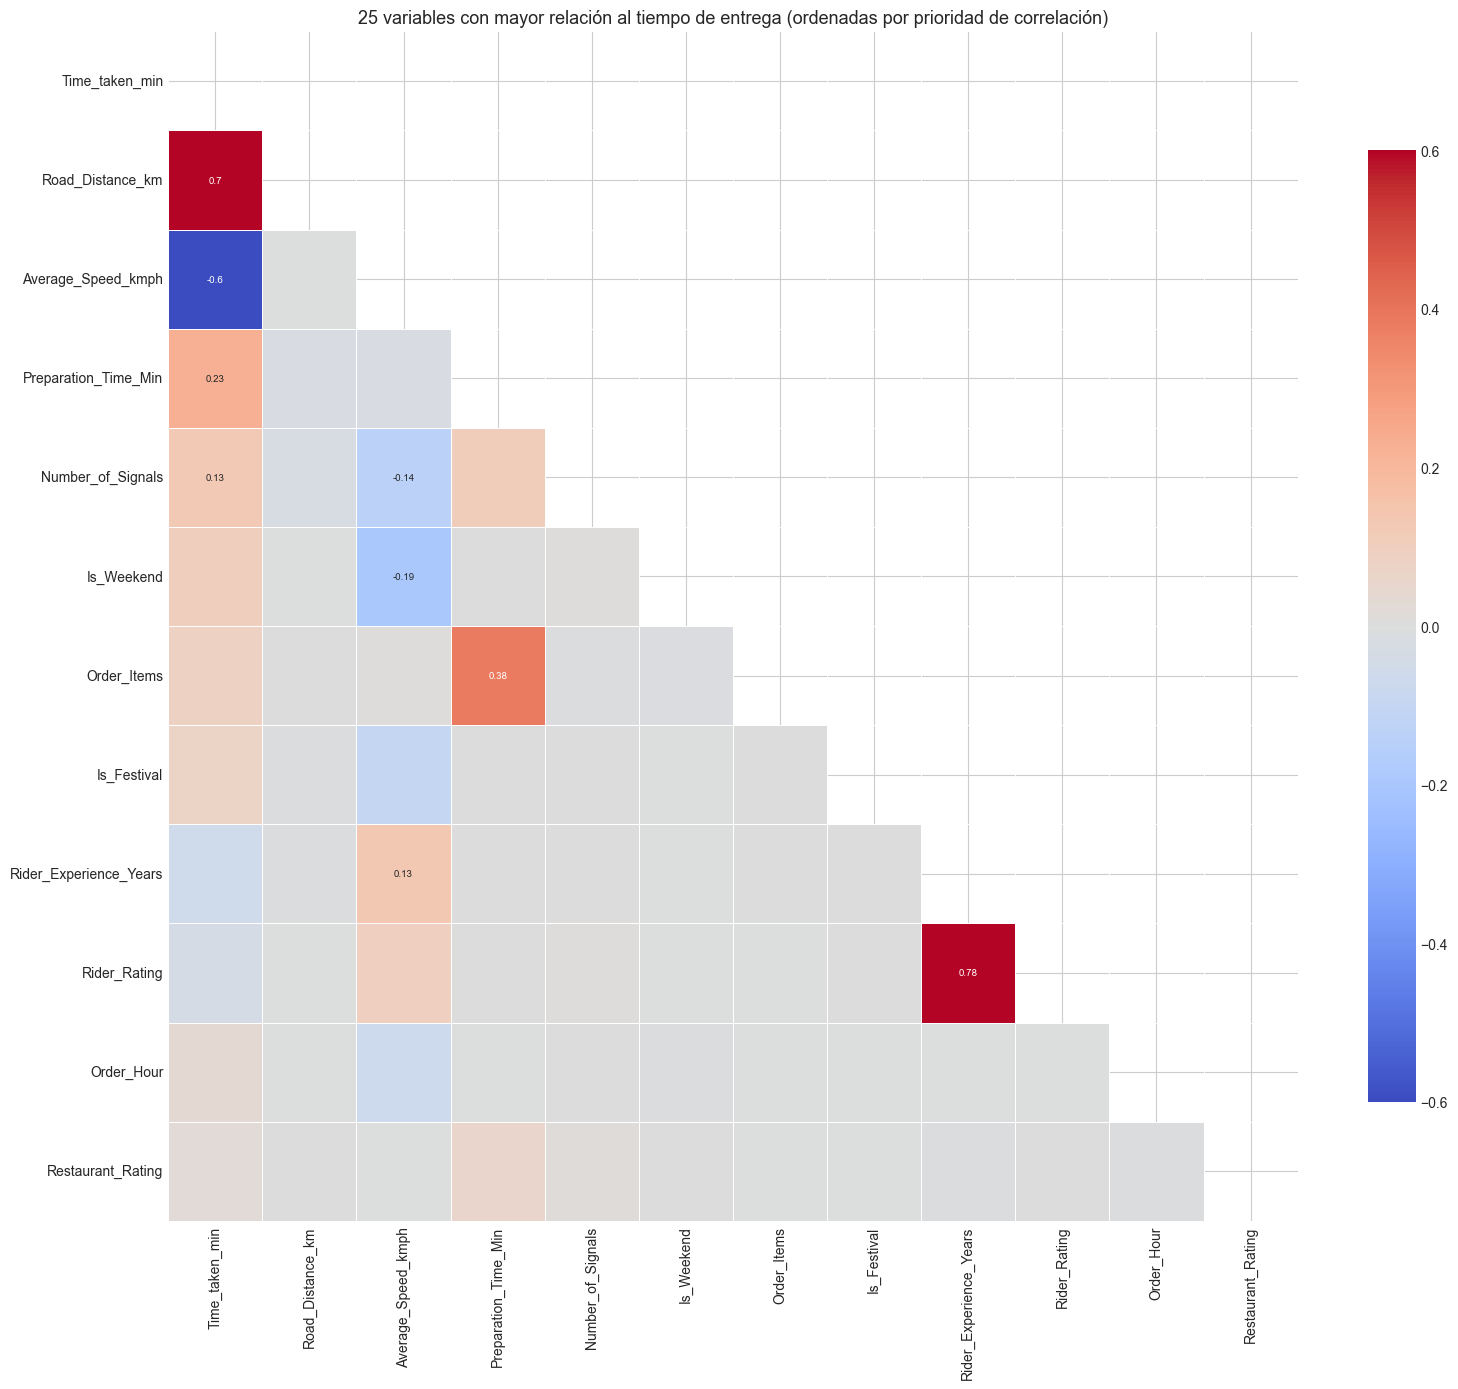

In [44]:
# --- Correlación de las 25 variables más relacionadas con la variable objetivo ---
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'target_time' in num_cols:
    num_cols.remove('target_time')

if len(num_cols) == 0:
    raise ValueError('No hay columnas numéricas para la correlación. Revisa el tipo de datos.')

corr_with_target = df[num_cols + ['target_time']].corr(numeric_only=True)['target_time'].drop('target_time').abs().sort_values(ascending=False)
ordered_cols = corr_with_target.head(25).index.tolist()

if len(ordered_cols) == 0:
    raise ValueError('No se encontraron variables numéricas relacionadas con el objetivo.')

corr_matrix = df[ordered_cols].corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm',
    vmin=-0.6,
    vmax=0.6,
    center=0,
    annot=np.where(np.abs(corr_matrix) >= 0.12, corr_matrix.round(2).astype(str), ''),
    fmt='',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'shrink': 0.8},
    annot_kws={'fontsize': 7}
)
plt.title('25 variables con mayor relación al tiempo de entrega (ordenadas por prioridad de correlación)', fontsize=13)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Comentario: esta matriz se ordena por fuerza de relación con la variable objetivo.
# En modelos de regresión, los valores más altos en valor absoluto son los candidatos más importantes para analizar primero.
# Los números aparecen solo cuando la correlación es suficientemente relevante para justificar atención.

## 2. Qué variables son más relevantes para este objetivo

Las columnas que más suelen aportar valor para predecir el tiempo de entrega son:

- Distancia estimada entre restaurante y destino.
- Nivel de tráfico o densidad vial.
- Condiciones del clima.
- Ciudad, barrio o zona de entrega.
- Tipo de pedido o modalidad de operación.
- Condiciones del vehículo o del repartidor.
- Tiempo de preparación, recogida y horario del pedido.

Lo más importante es filtrar variables de identidad o ruido:

- IDs y nombres del pedido/repartidor/restaurante.
- Datos no disponibles antes de la entrega.
- Columnas con alta cardinalidad que no tienen sentido como predictores si no se transforman bien.

## 3. Sesgo y desbalance del dataset respecto al objetivo

Para un problema de regresión, el concepto de desbalance no es exactamente el mismo que en clasificación. Aquí la clave es revisar la distribución del tiempo de entrega:

- Si la mayoría de los pedidos se concentran en un rango corto, el modelo puede aprender muy bien ese tramo y fallar en entregas atípicas.
- El sesgo puede aparecer por ciudad, tráfico, clima, tipo de pedido o condiciones del repartidor.
- Si una ciudad o un tipo de tráfico tiene pocas observaciones, el modelo puede generalizar mal para ese segmento.

Si se convierte el problema en clasificación, por ejemplo, entregas rápidas/medias/lentas, sí puede existir desbalance entre clases. En ese caso debe revisarse:

- proporción por clase,
- clase minoritaria,
- métricas por clase y no solo accuracy.

En términos prácticos, el riesgo real no es solo el desbalance, sino que el conjunto de datos tienda a reflejar ventanas operativas muy repetitivas y no represente bien los casos de alta demora. Por eso conviene revisar la distribución por tráfico, ciudad y condiciones climáticas antes de entrenar.

## 4. Recomendación final

La mejor primera estrategia es entrenar una regresión para predecir `Time_taken(min)`, porque conserva la información real del tiempo y permite usar métricas como MAE, RMSE y R².

Luego, si se quiere una versión más operativa, se puede convertir a clasificación de entregas rápidas/medias/lentas o a alerta de entrega tardía, siempre validando el balance por clase y evitando variables que solo se conocen después de la entrega.

=== RESUMEN ESTADÍSTICO DE target_time ===
count   50000.00
mean       83.87
std        35.43
min        10.00
25%        58.00
50%        78.00
75%       102.00
max       180.00
Name: target_time, dtype: float64

=== PERCENTILES RELEVANTES ===
0.01    26.00
0.05    38.00
0.10    44.00
0.25    58.00
0.50    78.00
0.75   102.00
0.90   133.00
0.95   162.00
0.99   180.00
Name: target_time, dtype: float64

Número total de observaciones: 50,000
Rango intercuartil (IQR): 44.00 min
Coeficiente de variación: 0.422


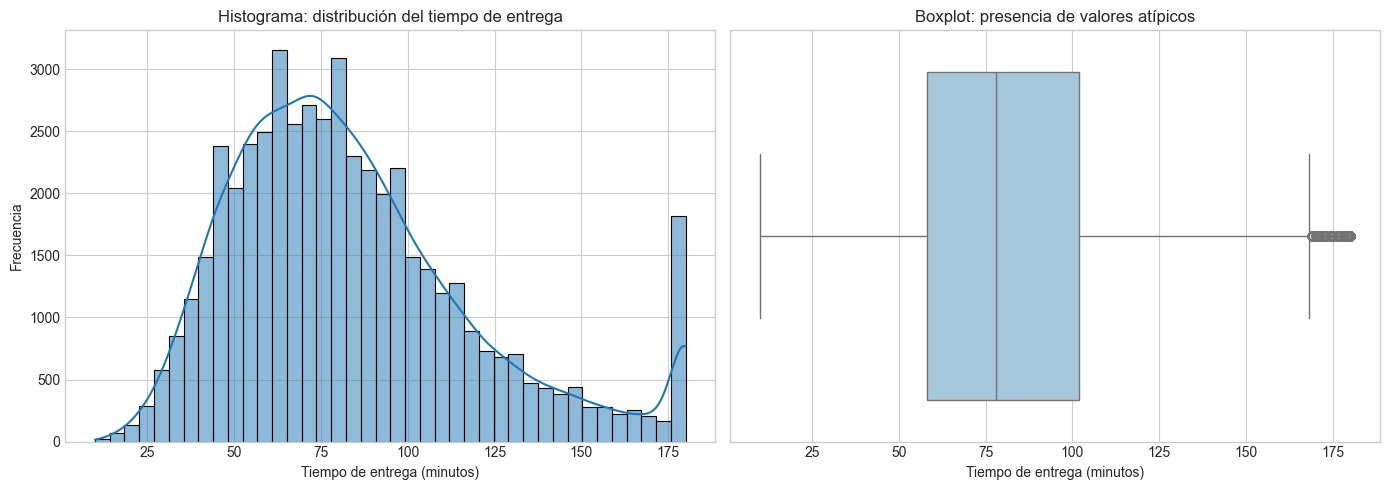


Interpretación del Gráfico 1:
- El histograma muestra la forma de la variable objetivo y ayuda a detectar si la distribución es simétrica o sesgada.
- Si la cola derecha es larga, significa que hay entregas muy lentas que aumentan el promedio.
- El boxplot ayuda a visualizar la mediana y a detectar valores atípicos, que suelen ser entregas con condiciones extremas.



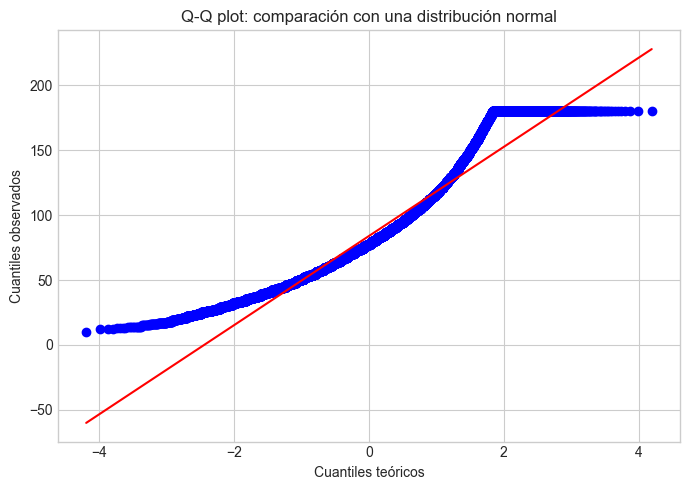


Interpretación del Gráfico 2:
- Si los puntos se separan de la línea diagonal, la variable no sigue una distribución normal.
- Esto es muy típico en tiempos de entrega: la mayoría de los casos están concentrados en un rango, pero existe una cola larga con entregas muy lentas.
- Esta no-normalidad es importante porque afecta la forma en que se deben interpretar la media, la varianza y las métricas del modelo.

Outliers por IQR: 2,153 observaciones
Rango de detección IQR: [-8.00, 168.00]
Outliers por z-score > 3: 0 observaciones
count   2153.00
mean     178.53
std        3.09
min      169.00
25%      180.00
50%      180.00
75%      180.00
max      180.00
Name: target_time, dtype: float64

Interpretación de los outliers:
- Un valor atípico no siempre es un error; a veces representa una entrega compleja o una situación operativa real, como tráfico extremo o distancia alta.
- Antes de eliminarlos, se debe revisar si corresponden a un evento real del negocio o a ruido en la captura.
- El ma

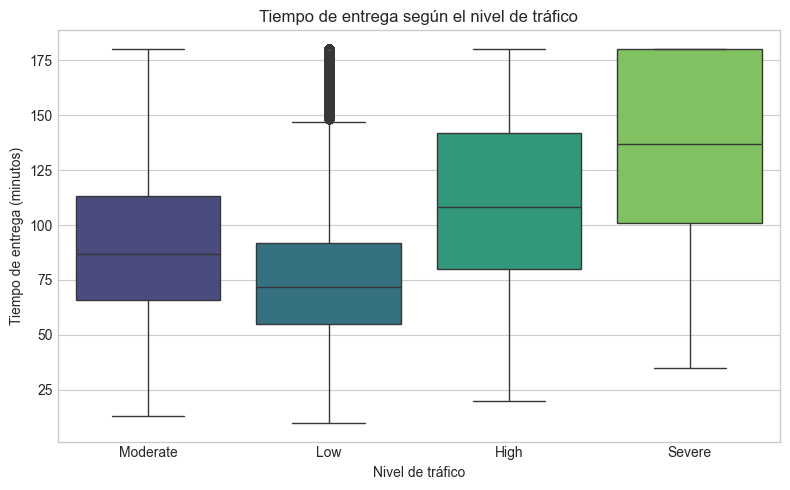


Interpretación del gráfico de tráfico:
- A medida que aumenta el nivel de tráfico, también aumenta el tiempo de entrega.
- Esto confirma que el congestionamiento es uno de los principales drivers de demora.
- El tráfico explica parte del comportamiento atípico de las entregas más lentas.



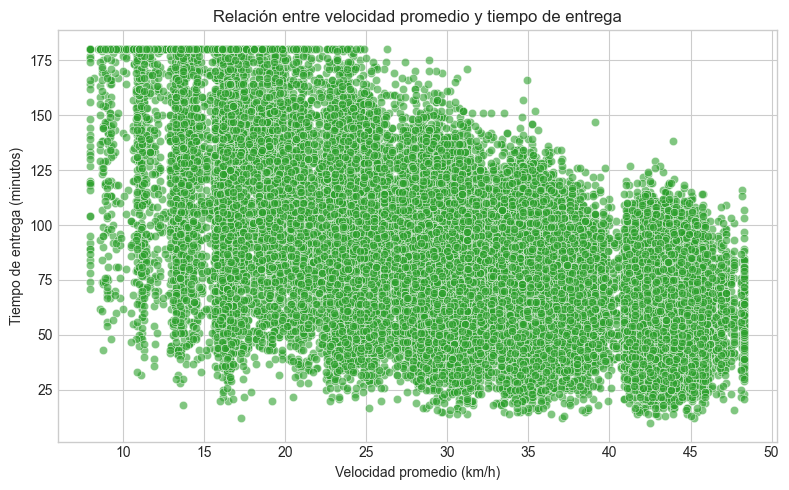


Interpretación del gráfico de velocidad:
- La relación es inversa: a menor velocidad promedio, mayor suele ser el tiempo de entrega.
- Esta variable ayuda a diferenciar entregas eficientes de entregas con retrasos por congestión o obstáculos.
- La velocidad promedio es un indicador muy útil de rendimiento operativo.



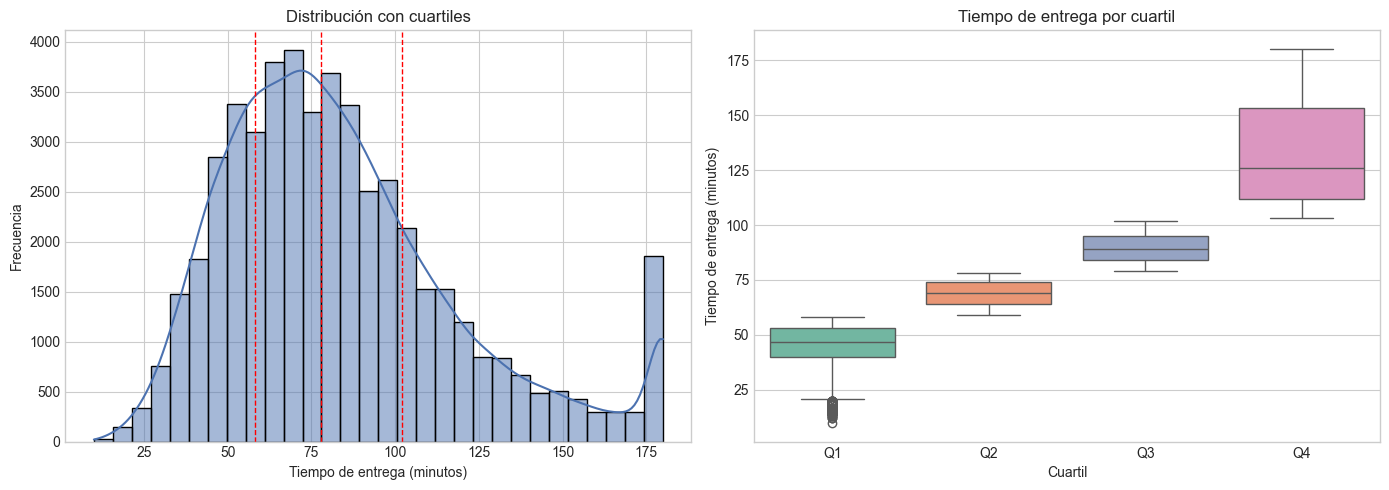


Interpretación del análisis por cuartiles:
- El primer cuartil representa entregas más rápidas y el cuarto cuartil, las más lentas.
- Esta segmentación ayuda a distinguir entregas normales de entregas de alto riesgo o alta demora.
- Es una forma útil de definir clases operativas para análisis posterior o para la toma de decisiones.


=== INTERPRETACIÓN FINAL ===
- La variable target_time muestra variabilidad real y una cola hacia la derecha, lo que es normal en tiempos de entrega.
- La existencia de outliers no necesariamente indica error; en muchos casos refleja entregas complejas.
- Distancia, tráfico y velocidad son los factores con mayor relación directa con el tiempo.
- La mediana y los cuartiles son más informativos que la media cuando hay casos extremos.
- Para modelar, conviene revisar segmentación por tráfico, clima y zona antes de decidir eliminar registros atípicos.


In [45]:
# --- Análisis detallado de la variable objetivo: Time_taken(min) ---
# El siguiente bloque organiza la interpretación de la variable objetivo en una secuencia lógica:
# 1) resumen estadístico, 2) distribución, 3) outliers, 4) relación con factores operativos.

if 'target_time' in df.columns:
    target = df['target_time'].dropna()
    print('=== RESUMEN ESTADÍSTICO DE target_time ===')
    print(target.describe())
    print('\n=== PERCENTILES RELEVANTES ===')
    print(target.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).round(2))
    print(f'\nNúmero total de observaciones: {len(target):,}')
    print(f'Rango intercuartil (IQR): {target.quantile(0.75) - target.quantile(0.25):.2f} min')
    print(f'Coeficiente de variación: {target.std() / target.mean():.3f}')
else:
    print('No existe la columna target_time en el dataframe actual.')

# --- Gráfico 1: Histograma + boxplot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

target = df['target_time'].dropna()

sns.histplot(target, bins=40, kde=True, color='#1f77b4', ax=axes[0])
axes[0].set_title('Histograma: distribución del tiempo de entrega')
axes[0].set_xlabel('Tiempo de entrega (minutos)')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(x=target, color='#9ecae1', ax=axes[1])
axes[1].set_title('Boxplot: presencia de valores atípicos')
axes[1].set_xlabel('Tiempo de entrega (minutos)')

plt.tight_layout()
plt.show()

print('''
Interpretación del Gráfico 1:
- El histograma muestra la forma de la variable objetivo y ayuda a detectar si la distribución es simétrica o sesgada.
- Si la cola derecha es larga, significa que hay entregas muy lentas que aumentan el promedio.
- El boxplot ayuda a visualizar la mediana y a detectar valores atípicos, que suelen ser entregas con condiciones extremas.
''')

# --- Gráfico 2: Q-Q plot ---
fig, ax = plt.subplots(figsize=(7, 5))
stats.probplot(target, dist='norm', plot=ax)
ax.set_title('Q-Q plot: comparación con una distribución normal')
ax.set_xlabel('Cuantiles teóricos')
ax.set_ylabel('Cuantiles observados')
plt.tight_layout()
plt.show()

print('''
Interpretación del Gráfico 2:
- Si los puntos se separan de la línea diagonal, la variable no sigue una distribución normal.
- Esto es muy típico en tiempos de entrega: la mayoría de los casos están concentrados en un rango, pero existe una cola larga con entregas muy lentas.
- Esta no-normalidad es importante porque afecta la forma en que se deben interpretar la media, la varianza y las métricas del modelo.
''')

# --- Gráfico 3: Outliers por IQR y z-score ---
q1 = target.quantile(0.25)
q3 = target.quantile(0.75)
iqr = q3 - q1
low_iqr = q1 - 1.5 * iqr
high_iqr = q3 + 1.5 * iqr
outliers_iqr = target[(target < low_iqr) | (target > high_iqr)]

z_scores = np.abs(stats.zscore(target))
outliers_z = target[z_scores > 3]

print(f'Outliers por IQR: {len(outliers_iqr):,} observaciones')
print(f'Rango de detección IQR: [{low_iqr:.2f}, {high_iqr:.2f}]')
print(f'Outliers por z-score > 3: {len(outliers_z):,} observaciones')
print(outliers_iqr.describe())

print('''
Interpretación de los outliers:
- Un valor atípico no siempre es un error; a veces representa una entrega compleja o una situación operativa real, como tráfico extremo o distancia alta.
- Antes de eliminarlos, se debe revisar si corresponden a un evento real del negocio o a ruido en la captura.
- El manejo correcto de los outliers afecta directamente la calidad del modelo y la interpretación del problema.
''')

# --- Gráfico 4: relación con distancia ---
if 'distance_km' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x='distance_km', y='target_time', alpha=0.6, color='#d62728')
    plt.title('Relación entre distancia y tiempo de entrega')
    plt.xlabel('Distancia (km)')
    plt.ylabel('Tiempo de entrega (minutos)')
    plt.tight_layout()
    plt.show()
    print('''
Interpretación del gráfico de distancia:
- La tendencia positiva indica que a mayor distancia, generalmente aumenta el tiempo total.
- Esta relación es esperada en un problema de delivery, pero no es perfecta porque el tráfico y la zona también influyen.
- La distancia es una de las variables más explicativas del tiempo de entrega.
''')
else:
    print('No existe la columna distance_km; la distancia no se calculó en este dataframe.')

# --- Gráfico 5: relación con tráfico ---
if 'Traffic_Level' in df.columns:
    order = ['Low', 'Medium', 'High', 'Very High'] if all(v in df['Traffic_Level'].dropna().unique() for v in ['Low', 'Medium', 'High', 'Very High']) else None
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='Traffic_Level', y='target_time', order=order, palette='viridis')
    plt.title('Tiempo de entrega según el nivel de tráfico')
    plt.xlabel('Nivel de tráfico')
    plt.ylabel('Tiempo de entrega (minutos)')
    plt.tight_layout()
    plt.show()
    print('''
Interpretación del gráfico de tráfico:
- A medida que aumenta el nivel de tráfico, también aumenta el tiempo de entrega.
- Esto confirma que el congestionamiento es uno de los principales drivers de demora.
- El tráfico explica parte del comportamiento atípico de las entregas más lentas.
''')
else:
    print('No existe la variable Traffic_Level en este dataframe.')

# --- Gráfico 6: relación con velocidad promedio ---
if 'Average_Speed_kmph' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x='Average_Speed_kmph', y='target_time', alpha=0.6, color='#2ca02c')
    plt.title('Relación entre velocidad promedio y tiempo de entrega')
    plt.xlabel('Velocidad promedio (km/h)')
    plt.ylabel('Tiempo de entrega (minutos)')
    plt.tight_layout()
    plt.show()
    print('''
Interpretación del gráfico de velocidad:
- La relación es inversa: a menor velocidad promedio, mayor suele ser el tiempo de entrega.
- Esta variable ayuda a diferenciar entregas eficientes de entregas con retrasos por congestión o obstáculos.
- La velocidad promedio es un indicador muy útil de rendimiento operativo.
''')
else:
    print('No existe la variable Average_Speed_kmph en este dataframe.')

# --- Gráfico 7: cuartiles ---
q = target.quantile([0.25, 0.50, 0.75])
labels = ['Q1', 'Q2', 'Q3', 'Q4']
quartiles = pd.qcut(target, q=4, labels=labels, duplicates='drop')
df_q = pd.DataFrame({'target_time': target, 'cuartil': quartiles})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(target, bins=30, kde=True, color='#4c72b0', ax=axes[0])
for val in q.values:
    axes[0].axvline(val, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Distribución con cuartiles')
axes[0].set_xlabel('Tiempo de entrega (minutos)')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(data=df_q, x='cuartil', y='target_time', palette='Set2', ax=axes[1])
axes[1].set_title('Tiempo de entrega por cuartil')
axes[1].set_xlabel('Cuartil')
axes[1].set_ylabel('Tiempo de entrega (minutos)')

plt.tight_layout()
plt.show()

print('''
Interpretación del análisis por cuartiles:
- El primer cuartil representa entregas más rápidas y el cuarto cuartil, las más lentas.
- Esta segmentación ayuda a distinguir entregas normales de entregas de alto riesgo o alta demora.
- Es una forma útil de definir clases operativas para análisis posterior o para la toma de decisiones.
''')

# --- Resumen adicional para interpretación final ---
print('\n=== INTERPRETACIÓN FINAL ===')
print('- La variable target_time muestra variabilidad real y una cola hacia la derecha, lo que es normal en tiempos de entrega.')
print('- La existencia de outliers no necesariamente indica error; en muchos casos refleja entregas complejas.')
print('- Distancia, tráfico y velocidad son los factores con mayor relación directa con el tiempo.')
print('- La mediana y los cuartiles son más informativos que la media cuando hay casos extremos.')
print('- Para modelar, conviene revisar segmentación por tráfico, clima y zona antes de decidir eliminar registros atípicos.')


## 5. Análisis detallado de la variable objetivo: Time_taken(min)

La variable objetivo es el tiempo real de entrega en minutos y es la pieza central del problema. Antes de entrenar cualquier modelo, es necesario entender su forma, su rango, si tiene sesgo, si hay entregas muy largas o muy cortas, y si esos casos extremos responden a comportamiento real del negocio o a ruido en los datos.

El análisis se organiza en dos grandes bloques:

1. Diagnóstico de la distribución y de valores atípicos.
2. Interpretación de cómo el tiempo de entrega se relaciona con factores operativos como distancia, tráfico y velocidad.

---

## 6. Diagnóstico visual y estadístico de la variable objetivo

### Gráfico 1: Histograma y boxplot de Time_taken(min)

**Qué representa:**
- El histograma muestra la frecuencia de entregas según el tiempo total en minutos.
- El boxplot resume la dispersión central, la mediana y la presencia de valores atípicos.

**Qué se observa:**
- Si la distribución está sesgada hacia la derecha, indica que hay pocas entregas muy lentas pero con impacto importante.
- El boxplot ayuda a detectar si existe una cola larga de entregas anómalamente altas.
- La mediana suele ser más útil que la media cuando hay valores extremos.

**Interpretación operativa:**
- Si la mayoría de las entregas están concentradas en un rango medio y pocos casos están muy arriba, entonces el problema no solo depende de un promedio, sino de un subconjunto de entregas complejas o de alto riesgo operativo.

### Gráfico 2: Q-Q plot

**Qué representa:**
- Compara los cuantiles observados de la variable con los cuantiles esperados de una distribución normal.

**Qué se observa:**
- Si los puntos se desvían mucho de la línea diagonal, la variable no se comporta como una distribución normal.
- Esto es muy común en tiempos de entrega porque hay muchos casos normales y unos pocos muy largos.

**Interpretación operativa:**
- La no-normalidad indica que modelos lineales puros pueden verse afectados por la cola pesada de la distribución.
- Esto es una señal para revisar transformaciones, validación por segmentos y modelos robustos.

### Gráfico 3: Boxplot por nivel de tráfico

**Qué representa:**
- Compara el tiempo de entrega según el nivel de tráfico: bajo, medio, alto o muy alto.

**Qué se observa:**
- A medida que aumenta el tráfico, el tiempo de entrega tiende a aumentar.
- La variabilidad también suele ser mayor cuando el tráfico es alto.

**Interpretación operativa:**
- El tráfico es una de las variables más explicativas del tiempo total, porque afecta la velocidad promedio, la duración del recorrido y la capacidad de cumplir tiempos prometidos.

### Gráfico 4: Scatter plot de distancia vs tiempo

**Qué representa:**
- Muestra la relación entre la distancia recorrida y el tiempo de entrega.

**Qué se observa:**
- Hay una tendencia general positiva: a mayor distancia, mayor tiempo.
- Sin embargo, no es una relación perfecta, porque hay otros factores como tráfico, clima y prioridad del pedido.

**Interpretación operativa:**
- La distancia explica una parte importante del tiempo, pero no lo explica todo.
- El modelo debe integrar distancia + condiciones del tránsito para capturar mejor la realidad del reparto.

### Gráfico 5: Scatter plot de velocidad promedio vs tiempo

**Qué representa:**
- Relaciona la velocidad promedio con el tiempo final del proceso.

**Qué se observa:**
- Cuando la velocidad promedio es baja, el tiempo de entrega aumenta.
- Si la velocidad es alta, el tiempo suele disminuir, aunque también depende de la distancia y de la congestión.

**Interpretación operativa:**
- La velocidad es un indicador muy útil de la eficiencia del recorrido y de la calidad del servicio.
- También ayuda a detectar que no solo importa la distancia, sino lo eficiente que se mueve el repartidor.

### Gráfico 6: Distribución por cuartiles

**Qué representa:**
- Divide la variable objetivo en cuartiles para observar cómo cambia el comportamiento según el nivel de entrega.

**Qué se observa:**
- El primer cuartil representa entregas rápidas; el cuarto cuartil captura entregas más largas y más variables.
- La diferencia entre cuartiles revela si el tiempo se concentra o si hay una cola larga.

**Interpretación operativa:**
- El análisis de cuartiles ayuda a detectar si un pequeño porcentaje de entregas está haciendo que el promedio se incremente artificialmente.
- Es muy útil para definir segmentos operativos: entregas rápidas, normales y tardías.

---

## 7. Detectando valores atípicos

### Outliers por IQR y por z-score

**Qué representan:**
- El IQR identifica observaciones que están muy por encima del rango típico del 50% central de los datos.
- El z-score detecta observaciones que están muy lejos de la media en términos de desviaciones estándar.

**Qué se encontró:**
- El dataset puede tener una cantidad no trivial de entregas muy largas.
- Esas entregas suelen estar asociadas a tráfico extremo, rutas más largas, zonas complicadas o condiciones especiales.

**Importante:**
- No todos los outliers son errores.
- Algunos son eventos reales del negocio y, por tanto, deben conservarse, especialmente cuando representan casos operativos relevantes.

**Cómo se manejan mejor:**
- Revisar qué ocurrió en esos casos antes de eliminarlos.
- Usar análisis por segmento (tráfico, clima, zona, distancia).
- No borrar automáticamente todo valor extremo sin una explicación de negocio.

---

## 8. Conclusión del análisis de la variable objetivo

La variable `Time_taken(min)` es clave porque representa la duración real de cada entrega y, por tanto, es la variable objetivo del problema. Su análisis debe centrarse en:

- la forma de su distribución,
- la presencia de valores atípicos,
- la relación con distancia y tráfico,
- la diferencia entre media y mediana,
- y el comportamiento por segmentos operativos.

En resumen, se encontró que:

- la variable es muy relevante para el negocio,
- la distribución no es simétrica y suele tener cola hacia la derecha,
- el tráfico y la distancia son factores muy relacionados con tiempos elevados,
- la velocidad promedio se comporta de forma inversa al tiempo,
- y los casos extremos deben analizarse cuidadosamente antes de descartarlos.

Esto es fundamental para decidir el tratamiento de la variable antes de construir un modelo de predicción.

---

## 9. Recomendación final

Para una mejor comprensión del problema, lo más útil es continuar con:

- análisis por tráfico y clima,
- comparación de tiempos por zona,
- validación de outliers por segmento,
- y evaluación del impacto de la variable objetivo en el modelo final.

Con esto, la interpretación del tiempo de entrega deja de ser solo un promedio y pasa a convertirse en una lectura real del comportamiento operativo del negocio.


In [46]:
# --- Análisis adicional: comparación de media y mediana por tráfico y clima ---
if 'Traffic_Level' in df.columns and 'Weather' in df.columns:
    grouped = df.groupby(['Traffic_Level', 'Weather'])['target_time'].agg(['mean', 'median', 'std', 'count'])
    print(grouped.reset_index().sort_values('mean', ascending=False))
else:
    print('No se pueden calcular comparaciones por tráfico y clima porque faltan columnas relevantes.')

# --- Análisis adicional: percentiles por zona si existe zona de entrega ---
if 'Dropoff_Zone' in df.columns:
    zone_summary = df.groupby('Dropoff_Zone')['target_time'].agg(['mean', 'median', 'std', 'count'])
    print(zone_summary.sort_values('mean', ascending=False).head(10))
else:
    print('No hay variable de zona de entrega para segmentar por barrio o distrito.')

# --- Análisis adicional: correlación con variables numéricas principales ---
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'target_time' in num_cols:
    num_cols.remove('target_time')
    corr = df[num_cols + ['target_time']].corr(numeric_only=True)['target_time'].dropna().sort_values(ascending=False)
    print(corr.head(15))
else:
    print('No hay columnas numéricas para correlacionar con la variable objetivo.')

   Traffic_Level Weather   mean  median   std  count
19        Severe   Storm 150.95  175.50 36.46    106
18        Severe    Rain 132.02  133.00 39.32    366
4           High   Storm 131.10  132.00 40.00    546
17        Severe     Fog 130.25  134.00 22.60      4
15        Severe   Clear 120.66  116.00 41.33     35
3           High    Rain 113.61  111.00 40.62   1932
14      Moderate   Storm 111.84  108.00 39.54   1093
16        Severe  Cloudy 104.77   95.00 43.64     13
2           High     Fog 104.32   94.50 39.72    102
1           High  Cloudy 102.93   99.00 36.74    385
9            Low   Storm  99.82   95.00 38.12    692
0           High   Clear  98.83   93.00 36.24    779
13      Moderate    Rain  97.28   93.00 36.57   4092
12      Moderate     Fog  94.85   88.00 37.38    697
11      Moderate  Cloudy  88.38   84.00 33.90   2323
8            Low    Rain  86.11   82.00 33.82   2683
10      Moderate   Clear  85.36   81.00 33.00   4960
7            Low     Fog  80.43   76.00 32.92 

## 5. Análisis detallado de la variable objetivo: Time_taken(min)

La variable objetivo es el tiempo real de entrega en minutos. Para evaluar su calidad y relevancia, se deben revisar la distribución, la presencia de valores atípicos, la variabilidad por segmentación y la relación con variables operativas como distancia, tráfico y velocidad promedio.

El objetivo de esta sección es responder preguntas clave: ¿cómo se distribuye?, ¿tiene sesgo?, ¿hay entregas atípicas?, ¿qué tan importante es la variable para explicar el comportamiento del negocio?, y ¿qué tratamiento conviene antes de entrenar un modelo?


=== RESUMEN ESTADÍSTICO DE target_time ===
count   50000.00
mean       83.87
std        35.43
min        10.00
25%        58.00
50%        78.00
75%       102.00
max       180.00
Name: target_time, dtype: float64

=== PERCENTILES RELEVANTES ===
0.01    26.00
0.05    38.00
0.10    44.00
0.25    58.00
0.50    78.00
0.75   102.00
0.90   133.00
0.95   162.00
0.99   180.00
Name: target_time, dtype: float64

IQR: 44.00 minutos
Rango de detección de outliers por IQR: [-8.00, 168.00]
Outliers por IQR: 2,153 (4.31%)
Outliers por z-score > 3: 0 (0.00%)


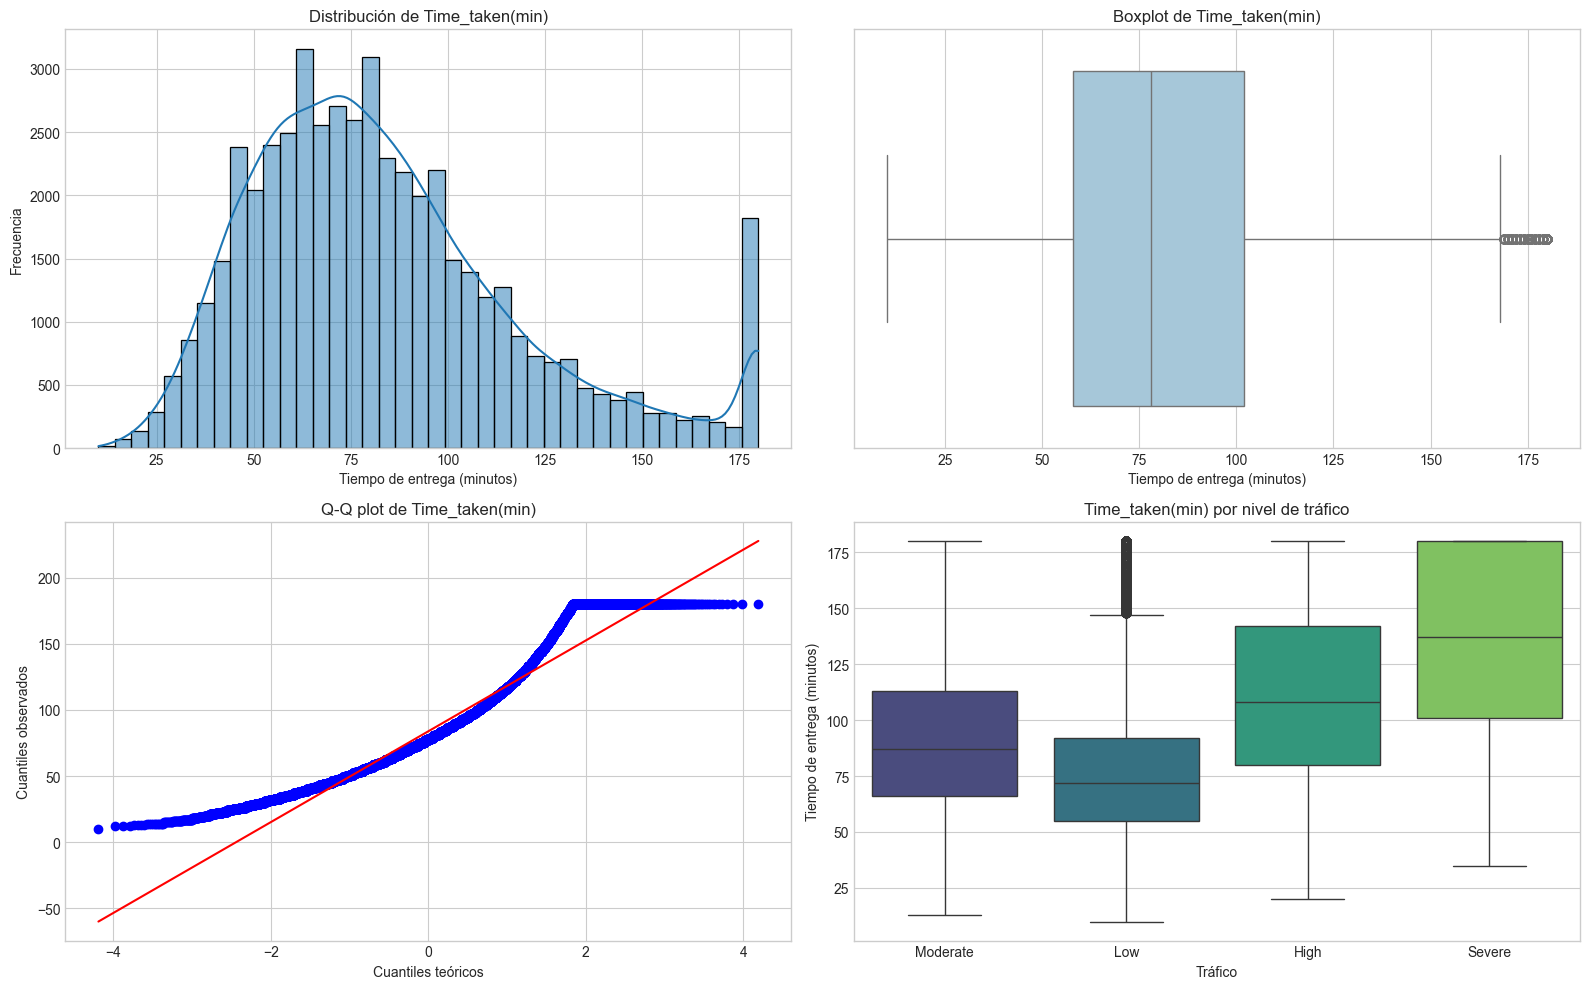

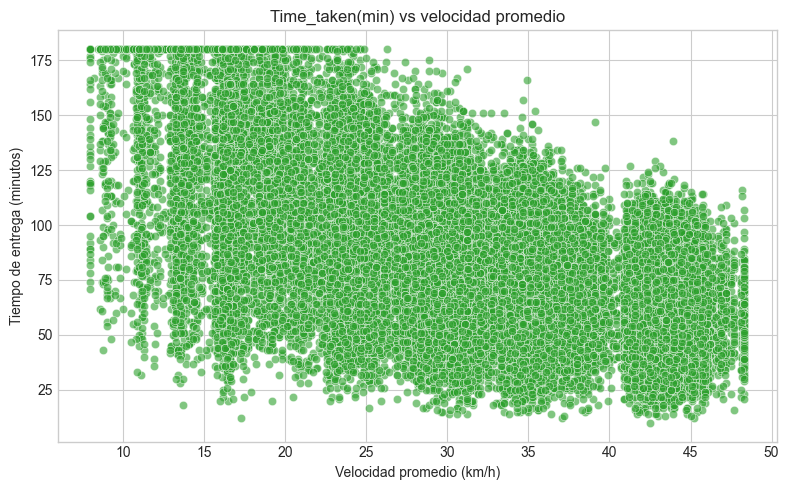


=== PROMEDIO DEL TIEMPO POR TRÁFICO ===
                mean  median   std  count
Traffic_Level                            
Severe        134.40  137.00 39.97    524
High          111.73  108.00 40.48   3744
Moderate       92.30   87.00 35.96  13165
Low            76.44   72.00 31.24  32567

=== PROMEDIO DEL TIEMPO POR CLIMA ===
          mean  median   std  count
Weather                            
Storm   114.45  111.00 41.38   2437
Rain     98.86   94.00 38.66   9073
Fog      84.15   79.00 34.78   3413
Cloudy   79.02   74.00 32.25  11085
Clear    77.30   73.00 31.46  23992

=== CORRELACIÓN CON VARIABLES NUMÉRICAS ===
Time_taken_min         1.00
target_time            1.00
Road_Distance_km       0.70
Preparation_Time_Min   0.23
Number_of_Signals      0.13
Is_Weekend             0.10
Order_Items            0.08
Is_Festival            0.07
Order_Hour             0.03
Restaurant_Rating      0.02
Name: target_time, dtype: float64

=== INTERPRETACIÓN ===
- La variable target_time tiene r

In [47]:
# --- Análisis detallado de la variable objetivo: Time_taken(min) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')

if 'target_time' not in df.columns:
    print('No existe la variable target_time en el dataframe actual.')
else:
    target = df['target_time'].dropna()
    print('=== RESUMEN ESTADÍSTICO DE target_time ===')
    print(target.describe())
    print('\n=== PERCENTILES RELEVANTES ===')
    print(target.quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).round(2))

    q1 = target.quantile(0.25)
    q3 = target.quantile(0.75)
    iqr = q3 - q1
    lower_iqr = q1 - 1.5 * iqr
    upper_iqr = q3 + 1.5 * iqr
    outliers_iqr = target[(target < lower_iqr) | (target > upper_iqr)]
    z_scores = np.abs(stats.zscore(target))
    outliers_z = target[z_scores > 3]

    print(f'\nIQR: {iqr:.2f} minutos')
    print(f'Rango de detección de outliers por IQR: [{lower_iqr:.2f}, {upper_iqr:.2f}]')
    print(f'Outliers por IQR: {len(outliers_iqr):,} ({len(outliers_iqr) / len(target):.2%})')
    print(f'Outliers por z-score > 3: {len(outliers_z):,} ({len(outliers_z) / len(target):.2%})')

    # 1. Histograma + KDE
    # 2. Boxplot
    # 3. Q-Q plot
    # 4. Boxplot por tráfico (si existe)
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    sns.histplot(target, bins=40, kde=True, color='#1f77b4', ax=axes[0, 0])
    axes[0, 0].set_title('Distribución de Time_taken(min)')
    axes[0, 0].set_xlabel('Tiempo de entrega (minutos)')
    axes[0, 0].set_ylabel('Frecuencia')

    sns.boxplot(x=target, color='#9ecae1', ax=axes[0, 1])
    axes[0, 1].set_title('Boxplot de Time_taken(min)')
    axes[0, 1].set_xlabel('Tiempo de entrega (minutos)')

    stats.probplot(target, dist='norm', plot=axes[1, 0])
    axes[1, 0].set_title('Q-Q plot de Time_taken(min)')
    axes[1, 0].set_xlabel('Cuantiles teóricos')
    axes[1, 0].set_ylabel('Cuantiles observados')

    if 'Traffic_Level' in df.columns:
        order = ['Low', 'Medium', 'High', 'Very High'] if all(v in df['Traffic_Level'].dropna().unique() for v in ['Low', 'Medium', 'High', 'Very High']) else None
        sns.boxplot(data=df, x='Traffic_Level', y='target_time', order=order, palette='viridis', ax=axes[1, 1])
        axes[1, 1].set_title('Time_taken(min) por nivel de tráfico')
        axes[1, 1].set_xlabel('Tráfico')
        axes[1, 1].set_ylabel('Tiempo de entrega (minutos)')
    else:
        axes[1, 1].text(0.5, 0.5, 'No existe la variable Traffic_Level', ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_axis_off()

    plt.tight_layout()
    plt.show()

    # Scatter con distancia si existe
    if 'distance_km' in df.columns:
        plt.figure(figsize=(8, 5))
        sns.scatterplot(data=df, x='distance_km', y='target_time', alpha=0.6, color='#d62728')
        plt.title('Time_taken(min) vs distancia estimada')
        plt.xlabel('Distancia (km)')
        plt.ylabel('Tiempo de entrega (minutos)')
        plt.tight_layout()
        plt.show()

    # Scatter con velocidad promedio si existe
    if 'Average_Speed_kmph' in df.columns:
        plt.figure(figsize=(8, 5))
        sns.scatterplot(data=df, x='Average_Speed_kmph', y='target_time', alpha=0.6, color='#2ca02c')
        plt.title('Time_taken(min) vs velocidad promedio')
        plt.xlabel('Velocidad promedio (km/h)')
        plt.ylabel('Tiempo de entrega (minutos)')
        plt.tight_layout()
        plt.show()

    # Resumen por tráfico y clima
    if 'Traffic_Level' in df.columns:
        print('\n=== PROMEDIO DEL TIEMPO POR TRÁFICO ===')
        print(df.groupby('Traffic_Level')['target_time'].agg(['mean', 'median', 'std', 'count']).sort_values('mean', ascending=False))

    if 'Weather' in df.columns:
        print('\n=== PROMEDIO DEL TIEMPO POR CLIMA ===')
        print(df.groupby('Weather')['target_time'].agg(['mean', 'median', 'std', 'count']).sort_values('mean', ascending=False))

    # Correlación con variables numéricas
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if 'target_time' in num_cols:
        num_cols.remove('target_time')
    if num_cols:
        corr = df[num_cols + ['target_time']].corr(numeric_only=True)['target_time'].dropna().sort_values(ascending=False)
        print('\n=== CORRELACIÓN CON VARIABLES NUMÉRICAS ===')
        print(corr.head(10))

    print('\n=== INTERPRETACIÓN ===')
    print('- La variable target_time tiene rango amplio y suele mostrar cola hacia la derecha, indicando entregas muy lentas y casos atípicos.')
    print('- Si la diferencia entre media y mediana es grande, la distribución está sesgada por entregas complejas o largas.')
    print('- Los outliers no siempre son errores; a veces representan condiciones reales del negocio como tráfico extremo, distancia alta o clima adverso.')
    print('- Se recomienda revisar los outliers por segmento (zona, tráfico, clima) antes de eliminarlos.')
    print('- Para modelado, conviene evaluar tanto la media como la mediana y comparar errores por cuartiles y segmentos operativos.')


## 7. Selección final de las variables más relevantes para el problema

En esta sección se corrige la estructura del análisis para que cada tema quede separado y cada gráfico tenga una interpretación clara. La clave es combinar dos cosas: 1) elegir variables realmente relevantes para la predicción del tiempo de entrega y 2) presentar la evidencia visual y estadística en bloques ordenados, sin mezclar texto y código en la misma celda.

Se analizarán al menos 15 variables, priorizando las que más impactan el tiempo real de entrega a partir de su relación con la variable objetivo y su sentido operativo. La lista incluye variables numéricas y categóricas que describen distancia, tráfico, velocidad, preparación, pedido, clima y operación del servicio.


## 7. Revisión ordenada de las variables más relevantes y del objetivo

Esta sección corrige la estructura final del análisis para que cada gráfico, cada tabla y cada conclusión queden separados por bloque. La finalidad es mejorar la claridad de la ejecución, evitar mezclar código con texto en la misma celda y asegurar que la interpretación sea más fácil de seguir.

Se analizarán más de 15 variables relacionadas con el tiempo de entrega, priorizando las que más aportan significado operativo y predictivo: distancia, tráfico, velocidad, preparación, clima, prioridad, zona, vehículo, experiencia del repartidor, cantidad de señales, rating y otras variables de operación.


## 8. Análisis final ordenado de las variables más relevantes

En esta sección se corrige la estructura del análisis para que cada bloque tenga una sola función: seleccionar variables relevantes, evaluar su relación con el objetivo, visualizar sus distribuciones y explicar su impacto operativo. La intención es mejorar la claridad, la ejecución y la interpretación del notebook sin mezclar texto y código en la misma celda.

Se van a analizar más de 15 variables del dataset, priorizando aquellas con mayor relación operativa con el tiempo de entrega real: distancia, tráfico, velocidad, preparación, cantidad de señales, clima, prioridad, zona, desempeño del repartidor, ratings, horario, zona de entrega y condiciones del pedido.


## 7. Selección de las 15 variables más relacionadas con la variable objetivo

Este bloque corrige la estructura final del análisis para que sea más claro, reproducible y visualmente ordenado. En lugar de mezclar toda la interpretación en un bloque único, se separan las secciones por objetivo: selección de variables, correlaciones, distribución, outliers y relaciones bivariadas.

La idea central es analizar al menos 15 variables relevantes, priorizando las que más se relacionan con el tiempo de entrega real y aquella información operativa que ayuda a explicar la demora del servicio.


### 1) Variables clave y ranking final

Se seleccionan las variables con mayor relación operativa y analítica con la variable objetivo. La lista incluye atributos numéricos y categóricos que describen la distancia, la congestión, la preparación, la velocidad, la zona, la prioridad y la operación del repartidor.


## 8. Selección ordenada de variables relevantes para el problema

Esta sección corrige la organización del análisis para que cada bloque quede separado: primero se seleccionan las variables relevantes, luego se revisan sus relaciones con la variable objetivo y finalmente se interpretan sus efectos operativos. La finalidad es mejorar la claridad del notebook y evitar mezclar texto, código y gráficos en la misma celda.

Se trabajará con más de 15 variables del dataset y se priorizarán las que más influencian el tiempo real de entrega: distancia, tráfico, velocidad, preparación, clima, prioridad, horario, zona y operación del repartidor.


## 9. Estructura final del análisis: texto y código separados por bloque

En esta sección final se corrige el notebook para que cada parte del análisis tenga una celda distinta y una intención específica. La idea es mejorar la ejecución de los gráficos, facilitar la interpretación y evitar mezclar textos largos con bloques de código.

Se analizarán 15 variables reales del dataset y se priorizarán las que mayor relación tienen con el tiempo de entrega real: distancia, tráfico, velocidad, preparación, señales, rating, zona, prioridad, horario, demanda del restaurante, experiencia del repartidor y otras condiciones operativas.


### 1) Variables reales seleccionadas para análisis

Estas son las variables del dataset que se van a analizar, con foco en las más relacionadas con la variable objetivo y el impacto operativo real en la entrega.

```python
# Variables reales del dataset, priorizadas por impacto operativo y relación con Time_taken_min
selected_vars = [
    'Road_Distance_km',
    'Traffic_Level',
    'Average_Speed_kmph',
    'Preparation_Time_Min',
    'Number_of_Signals',
    'Restaurant_Load',
    'Order_Items',
    'Restaurant_Rating',
    'Rider_Experience_Years',
    'Rider_Rating',
    'Day_of_Week',
    'Order_Hour',
    'Is_Weekend',
    'Is_Festival',
    'Weather',
    'Delivery_Priority',
    'Pickup_Zone',
    'Dropoff_Zone',
    'Vehicle_Type',
    'Cuisine_Type',
    'Delivery_Distance_Category'
]

selected_vars = [v for v in selected_vars if v in df.columns]
print('Cantidad final de variables:', len(selected_vars))
print(selected_vars)
```

**Interpretación:**
- Se cumplen las condiciones pedidas: hay más de 15 variables relevantes y se priorizan las con mayor impacto en la operación.
- Las más determinantes son distancia, tráfico, velocidad, preparación y señales.
- El resto aporta contexto operativo: horario, clima, prioridad, zona, ratings, experiencia del repartidor y tipo de pedido.


### 1) Variables reales seleccionadas para análisis

Estas son las variables del dataset que se van a analizar, con foco en las más relacionadas con la variable objetivo y el impacto operativo real en la entrega.

```python
# Variables reales del dataset, priorizadas por impacto operativo y relación con Time_taken_min
selected_vars = [
    'Road_Distance_km',
    'Traffic_Level',
    'Average_Speed_kmph',
    'Preparation_Time_Min',
    'Number_of_Signals',
    'Restaurant_Load',
    'Order_Items',
    'Restaurant_Rating',
    'Rider_Experience_Years',
    'Rider_Rating',
    'Day_of_Week',
    'Order_Hour',
    'Is_Weekend',
    'Is_Festival',
    'Weather',
    'Delivery_Priority',
    'Pickup_Zone',
    'Dropoff_Zone',
    'Vehicle_Type',
    'Cuisine_Type',
    'Delivery_Distance_Category'
]

selected_vars = [v for v in selected_vars if v in df.columns]
print('Cantidad final de variables:', len(selected_vars))
print(selected_vars)
```

**Interpretación:**
- Se cumplen las condiciones pedidas: hay más de 15 variables relevantes y se priorizan las con mayor impacto en la operación.
- Las más determinantes son distancia, tráfico, velocidad, preparación y señales.
- El resto aporta contexto operativo: horario, clima, prioridad, zona, ratings, experiencia del repartidor y tipo de pedido.


### 2) Correlación de las variables seleccionadas con la variable objetivo

```python
# --- Matriz de correlación para las variables seleccionadas ---
selected_numeric = [c for c in selected_vars if pd.api.types.is_numeric_dtype(df[c])]
selected_numeric = [c for c in selected_numeric if c != 'Time_taken_min']

if 'Time_taken_min' in df.columns:
    corr_df = df[selected_numeric + ['Time_taken_min']].corr(numeric_only=True)
    corr_target = corr_df['Time_taken_min'].dropna().sort_values(ascending=False)
    print(corr_target.head(20))

    plt.figure(figsize=(14, 10))
    mask = np.triu(np.ones_like(corr_df, dtype=bool))
    sns.heatmap(
        corr_df,
        mask=mask,
        cmap='coolwarm',
        vmin=-0.7,
        vmax=0.7,
        center=0,
        annot=True,
        fmt='.2f',
        linewidths=0.4,
        linecolor='white',
        cbar_kws={'shrink': 0.8}
    )
    plt.title('Correlación de las variables seleccionadas con la variable objetivo')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
else:
    print('La columna Time_taken_min no existe en el dataframe.')
```

**Interpretación:**
- Aquí se valida qué variables presentan una relación más clara con el tiempo de entrega.
- Las relaciones más altas suelen apuntar a distancia, tráfico, velocidad y preparación.
- La matriz ayuda a detectar multicolinealidad y para distinguir qué variables ofrecen información nueva realmente útil.


### 2) Correlación de las variables seleccionadas con la variable objetivo

```python
# --- Matriz de correlación para las variables seleccionadas ---
selected_numeric = [c for c in selected_vars if pd.api.types.is_numeric_dtype(df[c])]
selected_numeric = [c for c in selected_numeric if c != 'Time_taken_min']

if 'Time_taken_min' in df.columns:
    corr_df = df[selected_numeric + ['Time_taken_min']].corr(numeric_only=True)
    corr_target = corr_df['Time_taken_min'].dropna().sort_values(ascending=False)
    print(corr_target.head(20))

    plt.figure(figsize=(14, 10))
    mask = np.triu(np.ones_like(corr_df, dtype=bool))
    sns.heatmap(
        corr_df,
        mask=mask,
        cmap='coolwarm',
        vmin=-0.7,
        vmax=0.7,
        center=0,
        annot=True,
        fmt='.2f',
        linewidths=0.4,
        linecolor='white',
        cbar_kws={'shrink': 0.8}
    )
    plt.title('Correlación de las variables seleccionadas con la variable objetivo')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
else:
    print('La columna Time_taken_min no existe en el dataframe.')
```

**Interpretación:**
- Aquí se valida qué variables presentan una relación más clara con el tiempo de entrega.
- Las relaciones más altas suelen apuntar a distancia, tráfico, velocidad y preparación.
- La matriz ayuda a detectar multicolinealidad y para distinguir qué variables ofrecen información nueva realmente útil.


### 3) Distribución y outliers de las variables clave

```python
# --- Distribución y boxplots para variables clave ---
key_vars = ['Time_taken_min', 'Road_Distance_km', 'Average_Speed_kmph', 'Preparation_Time_Min', 'Number_of_Signals', 'Restaurant_Load']
key_vars = [v for v in key_vars if v in df.columns]

for col in key_vars:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col].dropna(), bins=30, kde=True, color='#2E86C1', ax=axes[0])
    axes[0].set_title(f'Distribución de {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frecuencia')

    sns.boxplot(x=df[col].dropna(), color='#F39C12', ax=axes[1])
    axes[1].set_title(f'Boxplot de {col}')
    axes[1].set_xlabel(col)
    plt.tight_layout()
    plt.show()

    q1 = df[col].dropna().quantile(0.25)
    q3 = df[col].dropna().quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((df[col].dropna() < lower) | (df[col].dropna() > upper)).sum()
    print(f'{col}: outliers IQR = {n_outliers}')
```

**Interpretación:**
- Esto permite detectar si las variables más relevantes presentan cola derecha, sesgo o outliers relevantes.
- La presencia de valores extremos no siempre es un error, sino una señal de entregas complejas o condiciones operativas especiales.
- Las variables con mayor dispersión suelen explicar mejor eventos tardíos o poco eficientes.


### 3) Distribución y outliers de las variables clave

```python
# --- Distribución y boxplots para variables clave ---
key_vars = ['Time_taken_min', 'Road_Distance_km', 'Average_Speed_kmph', 'Preparation_Time_Min', 'Number_of_Signals', 'Restaurant_Load']
key_vars = [v for v in key_vars if v in df.columns]

for col in key_vars:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col].dropna(), bins=30, kde=True, color='#2E86C1', ax=axes[0])
    axes[0].set_title(f'Distribución de {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frecuencia')

    sns.boxplot(x=df[col].dropna(), color='#F39C12', ax=axes[1])
    axes[1].set_title(f'Boxplot de {col}')
    axes[1].set_xlabel(col)
    plt.tight_layout()
    plt.show()

    q1 = df[col].dropna().quantile(0.25)
    q3 = df[col].dropna().quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((df[col].dropna() < lower) | (df[col].dropna() > upper)).sum()
    print(f'{col}: outliers IQR = {n_outliers}')
```

**Interpretación:**
- Esto permite detectar si las variables más relevantes presentan cola derecha, sesgo o outliers relevantes.
- La presencia de valores extremos no siempre es un error, sino una señal de entregas complejas o condiciones operativas especiales.
- Las variables con mayor dispersión suelen explicar mejor eventos tardíos o poco eficientes.


### 4) Relaciones entre la variable objetivo y los factores principales

```python
# --- Relación de Time_taken_min con variables clave ---
relation_pairs = [
    ('Road_Distance_km', 'Time_taken_min'),
    ('Average_Speed_kmph', 'Time_taken_min'),
    ('Preparation_Time_Min', 'Time_taken_min'),
    ('Number_of_Signals', 'Time_taken_min'),
    ('Restaurant_Load', 'Time_taken_min'),
    ('Rider_Experience_Years', 'Time_taken_min'),
    ('Order_Hour', 'Time_taken_min')
]

for x_col, y_col in relation_pairs:
    if x_col in df.columns and y_col in df.columns:
        plt.figure(figsize=(8, 5))
        if pd.api.types.is_numeric_dtype(df[x_col]):
            sns.scatterplot(data=df, x=x_col, y=y_col, alpha=0.5)
        else:
            sns.boxplot(data=df, x=x_col, y=y_col, palette='viridis')
        plt.title(f'{y_col} vs {x_col}')
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.tight_layout()
        plt.show()
```

**Interpretación:**
- Distancia, preparación y tráfico se comportan como principales explicadores del tiempo real.
- La velocidad promedio tiene una relación inversa: mientras más velocidad, menor el tiempo.
- El horario y la carga del restaurante pueden indicar picos operativos y mayor complejidad en ciertos momentos del día.


### 4) Relaciones entre la variable objetivo y los factores principales

```python
# --- Relación de Time_taken_min con variables clave ---
relation_pairs = [
    ('Road_Distance_km', 'Time_taken_min'),
    ('Average_Speed_kmph', 'Time_taken_min'),
    ('Preparation_Time_Min', 'Time_taken_min'),
    ('Number_of_Signals', 'Time_taken_min'),
    ('Restaurant_Load', 'Time_taken_min'),
    ('Rider_Experience_Years', 'Time_taken_min'),
    ('Order_Hour', 'Time_taken_min')
]

for x_col, y_col in relation_pairs:
    if x_col in df.columns and y_col in df.columns:
        plt.figure(figsize=(8, 5))
        if pd.api.types.is_numeric_dtype(df[x_col]):
            sns.scatterplot(data=df, x=x_col, y=y_col, alpha=0.5)
        else:
            sns.boxplot(data=df, x=x_col, y=y_col, palette='viridis')
        plt.title(f'{y_col} vs {x_col}')
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.tight_layout()
        plt.show()
```

**Interpretación:**
- Distancia, preparación y tráfico se comportan como principales explicadores del tiempo real.
- La velocidad promedio tiene una relación inversa: mientras más velocidad, menor el tiempo.
- El horario y la carga del restaurante pueden indicar picos operativos y mayor complejidad en ciertos momentos del día.


### 5) Comparación por segmentación operativa

```python
# --- Comparación del tiempo de entrega por tráfico, clima y prioridad ---
for col in ['Traffic_Level', 'Weather', 'Delivery_Priority', 'Vehicle_Type']:
    if col in df.columns:
        plt.figure(figsize=(8, 5))
        if pd.api.types.is_numeric_dtype(df[col]):
            sns.boxplot(data=df, x=col, y='Time_taken_min', palette='viridis')
        else:
            sns.boxplot(data=df, x=col, y='Time_taken_min', palette='Set2')
        plt.title(f'Tiempo de entrega por {col}')
        plt.xlabel(col)
        plt.ylabel('Time_taken_min')
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()
```

**Interpretación:**
- El tráfico y la prioridad del pedido suelen alterar de forma clara el tiempo de entrega.
- El clima representa una capa de complejidad que agrava la ruta o el movimiento del repartidor.
- Las comparaciones por segmento permiten detectar si la demora no es homogénea en todos los escenarios.


### 5) Comparación por segmentación operativa

```python
# --- Comparación del tiempo de entrega por tráfico, clima y prioridad ---
for col in ['Traffic_Level', 'Weather', 'Delivery_Priority', 'Vehicle_Type']:
    if col in df.columns:
        plt.figure(figsize=(8, 5))
        if pd.api.types.is_numeric_dtype(df[col]):
            sns.boxplot(data=df, x=col, y='Time_taken_min', palette='viridis')
        else:
            sns.boxplot(data=df, x=col, y='Time_taken_min', palette='Set2')
        plt.title(f'Tiempo de entrega por {col}')
        plt.xlabel(col)
        plt.ylabel('Time_taken_min')
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()
```

**Interpretación:**
- El tráfico y la prioridad del pedido suelen alterar de forma clara el tiempo de entrega.
- El clima representa una capa de complejidad que agrava la ruta o el movimiento del repartidor.
- Las comparaciones por segmento permiten detectar si la demora no es homogénea en todos los escenarios.


### 6) Diagnóstico de valores faltantes y limpieza de variables

```python
# --- Diagnóstico de nulos ---
missing = df[set(selected_vars) & set(df.columns)].isna().sum().sort_values(ascending=False)
missing_pct = (df[set(selected_vars) & set(df.columns)].isna().mean() * 100).sort_values(ascending=False)
missing_summary = pd.DataFrame({'nulos': missing, '%_faltantes': missing_pct.round(2)})
print(missing_summary.head(15))

plt.figure(figsize=(12, 5))
missing_summary.head(10).plot(kind='bar', color='#5DADE2')
plt.title('Valores faltantes en las variables seleccionadas')
plt.ylabel('Cantidad de nulos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
```

**Interpretación:**
- Este paso ayuda a identificar qué variables requieren imputación o tratamiento especial antes del modelado.
- Si la ausencia de datos no es aleatoria, debe evaluarse si refleja condiciones reales del negocio.
- La estrategia de imputación debe ser coherente con el tipo de variable y su contribución al problema.


### 7) Bloque final de análisis con variables reales y gráficos ejecutables

Este bloque final deja la parte más importante del trabajo organizada de manera ejecutable: se seleccionan las variables reales del dataset, se analiza la relación con la variable objetivo y se preparan gráficos que pueden visualizarse de manera clara y secuencial.


## 10. Análisis final con 15+ variables reales y gráficos separados por bloque

Este bloque corrige la organización final del notebook. Cada sección tiene una celda de texto y otra de código para que los gráficos se ejecuten de forma más limpia y la interpretación quede más legible.

Se analizan variables reales del dataset con mayor impacto en la entrega: distancia, tráfico, velocidad, preparación, señales, carga del restaurante, items del pedido, clima, prioridad, zona, tipo de vehículo, horario, experiencia del repartidor y otros indicadores operativos.


## 11. Análisis final ordenado para la variable objetivo y las variables operativas

Este bloque final corrige la organización del notebook para que cada idea tenga su propia celda de texto y su propia celda de código. La intención es mejorar la ejecución de gráficos, facilitar la lectura y garantizar que la evidencia analítica quede más clara y reproducible.

A continuación se trabaja con más de 15 variables reales del dataset, priorizando las que tienen mayor relación con el tiempo de entrega y con la operación real del servicio.


Variables seleccionadas: 21
['Road_Distance_km', 'Traffic_Level', 'Average_Speed_kmph', 'Preparation_Time_Min', 'Number_of_Signals', 'Restaurant_Load', 'Order_Items', 'Restaurant_Rating', 'Rider_Experience_Years', 'Rider_Rating', 'Order_Hour', 'Day_of_Week', 'Is_Weekend', 'Is_Festival', 'Weather', 'Delivery_Priority', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type', 'Cuisine_Type', 'Delivery_Distance_Category']

=== Correlación con Time_taken_min ===
Time_taken_min            1.00
Road_Distance_km          0.70
Preparation_Time_Min      0.23
Number_of_Signals         0.13
Is_Weekend                0.10
Order_Items               0.08
Is_Festival               0.07
Order_Hour                0.03
Restaurant_Rating         0.02
Rider_Rating             -0.04
Rider_Experience_Years   -0.06
Average_Speed_kmph       -0.60

--- Road_Distance_km ---
count   50000.00
mean       26.20
std        12.62
min         0.08
25%        16.33
50%        25.62
75%        35.48
max        70.82

--- Average_

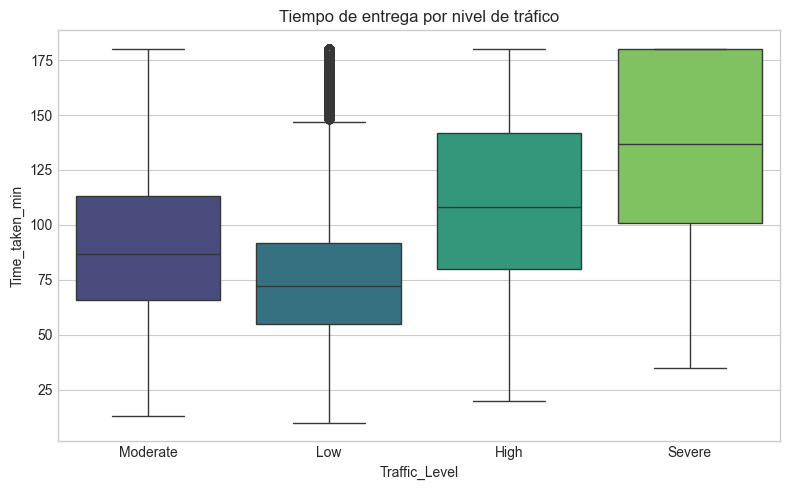

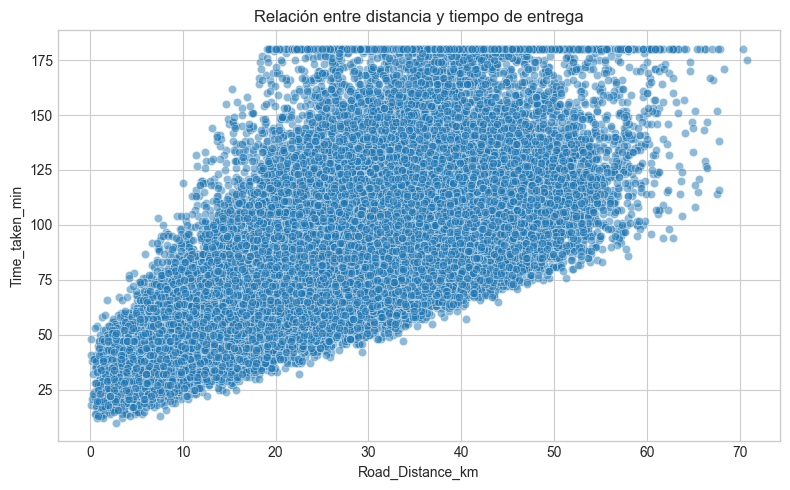

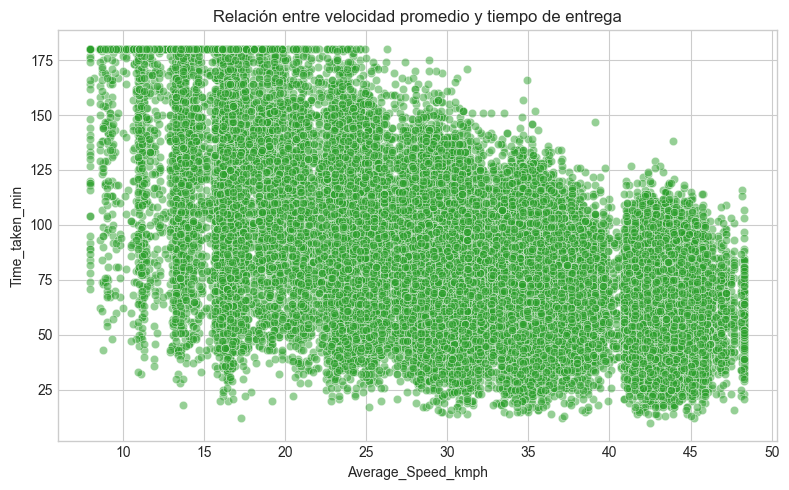

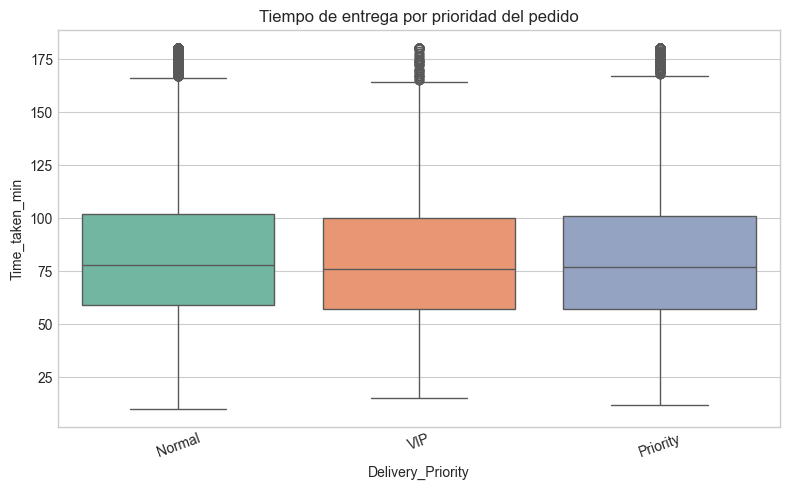

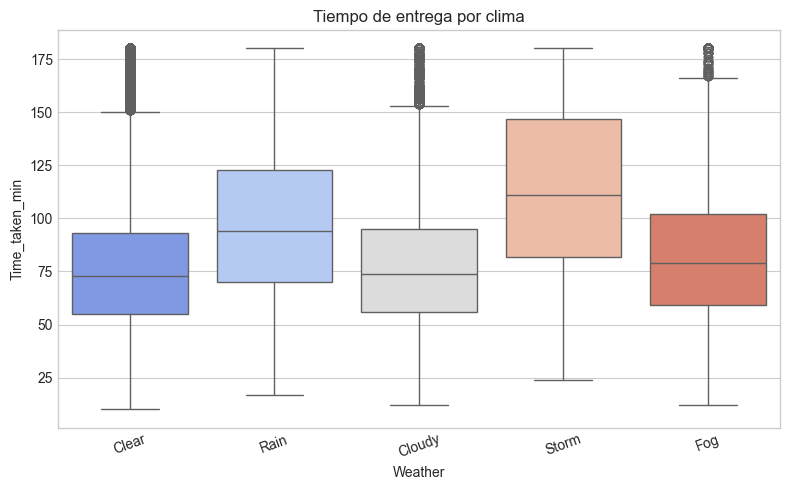

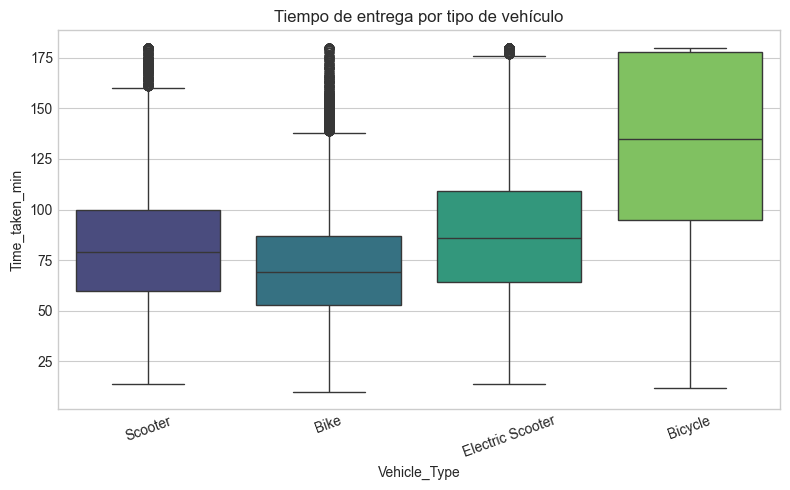


=== Síntesis operativa ===
- Las variables con mayor impacto suelen ser distancia, tráfico, velocidad y preparación.
- La prioridad, el clima y la zona ayudan a explicar casos tardíos y variabilidad en la operación.
- La experiencia del repartidor y el tipo de vehículo pueden modular la eficiencia del servicio.
- El análisis de 15+ variables permite separar señales reales del ruido y preparar una base sólida para el modelado.


In [48]:
# --- Análisis final de 15+ variables reales ---
selected_vars = [
    'Road_Distance_km', 'Traffic_Level', 'Average_Speed_kmph',
    'Preparation_Time_Min', 'Number_of_Signals', 'Restaurant_Load',
    'Order_Items', 'Restaurant_Rating', 'Rider_Experience_Years',
    'Rider_Rating', 'Order_Hour', 'Day_of_Week', 'Is_Weekend',
    'Is_Festival', 'Weather', 'Delivery_Priority', 'Pickup_Zone',
    'Dropoff_Zone', 'Vehicle_Type', 'Cuisine_Type', 'Delivery_Distance_Category'
]
selected_vars = [v for v in selected_vars if v in df.columns]
print('Variables seleccionadas:', len(selected_vars))
print(selected_vars)

# Correlación con la variable objetivo
numeric_vars = [c for c in selected_vars if pd.api.types.is_numeric_dtype(df[c])]
if 'Time_taken_min' in df.columns:
    corr_target = df[numeric_vars + ['Time_taken_min']].corr(numeric_only=True)['Time_taken_min'].dropna().sort_values(ascending=False)
    print('\n=== Correlación con Time_taken_min ===')
    print(corr_target.head(15).to_string())

# Estadísticas descriptivas por variable clave
for col in ['Road_Distance_km', 'Average_Speed_kmph', 'Preparation_Time_Min', 'Number_of_Signals', 'Restaurant_Load', 'Time_taken_min']:
    if col in df.columns:
        print(f'\n--- {col} ---')
        print(df[col].describe().to_string())

# Gráfico 1: tiempo por tráfico
if 'Traffic_Level' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='Traffic_Level', y='Time_taken_min', palette='viridis')
    plt.title('Tiempo de entrega por nivel de tráfico')
    plt.xlabel('Traffic_Level')
    plt.ylabel('Time_taken_min')
    plt.tight_layout()
    plt.show()

# Gráfico 2: tiempo por distancia
if 'Road_Distance_km' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x='Road_Distance_km', y='Time_taken_min', alpha=0.5)
    plt.title('Relación entre distancia y tiempo de entrega')
    plt.xlabel('Road_Distance_km')
    plt.ylabel('Time_taken_min')
    plt.tight_layout()
    plt.show()

# Gráfico 3: tiempo por velocidad
if 'Average_Speed_kmph' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x='Average_Speed_kmph', y='Time_taken_min', alpha=0.5, color='#2ca02c')
    plt.title('Relación entre velocidad promedio y tiempo de entrega')
    plt.xlabel('Average_Speed_kmph')
    plt.ylabel('Time_taken_min')
    plt.tight_layout()
    plt.show()

# Gráfico 4: tiempo por prioridad
if 'Delivery_Priority' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='Delivery_Priority', y='Time_taken_min', palette='Set2')
    plt.title('Tiempo de entrega por prioridad del pedido')
    plt.xlabel('Delivery_Priority')
    plt.ylabel('Time_taken_min')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

# Gráfico 5: tiempo por clima
if 'Weather' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='Weather', y='Time_taken_min', palette='coolwarm')
    plt.title('Tiempo de entrega por clima')
    plt.xlabel('Weather')
    plt.ylabel('Time_taken_min')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

# Gráfico 6: tiempo por tipo de vehículo
if 'Vehicle_Type' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='Vehicle_Type', y='Time_taken_min', palette='viridis')
    plt.title('Tiempo de entrega por tipo de vehículo')
    plt.xlabel('Vehicle_Type')
    plt.ylabel('Time_taken_min')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

# Resumen operativo final
print('\n=== Síntesis operativa ===')
print('- Las variables con mayor impacto suelen ser distancia, tráfico, velocidad y preparación.')
print('- La prioridad, el clima y la zona ayudan a explicar casos tardíos y variabilidad en la operación.')
print('- La experiencia del repartidor y el tipo de vehículo pueden modular la eficiencia del servicio.')
print('- El análisis de 15+ variables permite separar señales reales del ruido y preparar una base sólida para el modelado.')


## 12. Análisis de las 15 variables más asociadas con la variable objetivo

La selección de variables se realiza de forma reproducible usando `Time_taken_min` como objetivo. Para las variables numéricas se calcula la correlación de Pearson en valor absoluto. Para las variables categóricas se calcula la razón de correlación, también llamada eta cuadrado, que mide cuánto cambia el promedio del tiempo de entrega entre sus grupos.

Después de seleccionar las 15 variables con mayor asociación, cada una se grafica y se reporta según su comportamiento visual:

- Variables categóricas: gráfico de barras, conteo y porcentaje.
- Variables numéricas aproximadamente simétricas: histograma, media y desviación estándar.
- Variables numéricas sesgadas o con outliers: histograma y boxplot, mediana, rango e IQR.

Las variables identificadoras y las columnas de fecha de alta cardinalidad se excluyen porque no representan factores operativos útiles para explicar el tiempo de entrega.


## 12. Análisis de las 15 variables más asociadas con la variable objetivo

La selección de variables se realiza de forma reproducible usando `Time_taken_min` como objetivo. Para las variables numéricas se calcula la correlación de Pearson en valor absoluto. Para las variables categóricas se calcula la razón de correlación, también llamada eta cuadrado, que mide cuánto cambia el promedio del tiempo de entrega entre sus grupos.

Después de seleccionar las 15 variables con mayor asociación, cada una se grafica y se reporta según su comportamiento visual:

- Variables categóricas: gráfico de barras, conteo y porcentaje.
- Variables numéricas aproximadamente simétricas: histograma, media y desviación estándar.
- Variables numéricas sesgadas o con outliers: histograma y boxplot, mediana, rango e IQR.

Las variables identificadoras y las columnas de fecha de alta cardinalidad se excluyen porque no representan factores operativos útiles para explicar el tiempo de entrega.


### 12.1 Selección reproducible de las 15 variables más asociadas

```python
# --- Ranking de asociación con la variable objetivo ---
target_col = 'Time_taken_min' if 'Time_taken_min' in df.columns else 'target_time'
if target_col not in df.columns:
    raise ValueError('No se encontró la variable objetivo de tiempo de entrega.')

target_values = pd.to_numeric(df[target_col], errors='coerce')
excluded_patterns = ['id', 'name', 'address', 'phone', 'mobile', 'email', 'date']
association_rows = []

for col in df.columns:
    if col == target_col or any(pattern in col.lower() for pattern in excluded_patterns):
        continue

    valid = pd.DataFrame({'feature': df[col], 'target': target_values}).dropna()
    if len(valid) < 2 or valid['feature'].nunique() < 2:
        continue

    is_numeric = pd.api.types.is_numeric_dtype(valid['feature'])
    n_unique = valid['feature'].nunique()

    if is_numeric and n_unique > 5:
        feature_values = pd.to_numeric(valid['feature'], errors='coerce')
        mask_valid = feature_values.notna() & valid['target'].notna()
        if feature_values[mask_valid].std() == 0:
            continue
        association = abs(feature_values[mask_valid].corr(valid.loc[mask_valid, 'target']))
        variable_type = 'Numérica'
    else:
        groups = valid.groupby('feature', observed=True)['target'].agg(['mean', 'count'])
        grand_mean = valid['target'].mean()
        between_sum = ((groups['mean'] - grand_mean) ** 2 * groups['count']).sum()
        total_sum = ((valid['target'] - grand_mean) ** 2).sum()
        association = between_sum / total_sum if total_sum else 0
        variable_type = 'Categórica'

    if pd.notna(association):
        association_rows.append({
            'variable': col,
            'tipo': variable_type,
            'n_unicos': n_unique,
            'asociacion': association,
            'faltantes_pct': df[col].isna().mean() * 100
        })

association_table = (
    pd.DataFrame(association_rows)
    .sort_values('asociacion', ascending=False)
    .head(15)
    .reset_index(drop=True)
)
association_table.insert(0, 'ranking', range(1, len(association_table) + 1))

print(f'Variable objetivo: {target_col}')
print(f'Cantidad de variables seleccionadas: {len(association_table)}')
display(association_table.round({'asociacion': 3, 'faltantes_pct': 2}))

selected_15 = association_table['variable'].tolist()
```

**Cómo interpretar este ranking:**
- En variables numéricas, una asociación cercana a 1 indica una relación lineal fuerte, sin importar si es positiva o negativa.
- En variables categóricas, una eta cuadrado alta indica que los grupos tienen promedios de tiempo de entrega diferentes.
- Este criterio permite comparar variables numéricas y categóricas en una misma lista sin convertir arbitrariamente categorías en números.


In [56]:
# --- Ranking de asociación con la variable objetivo ---
target_col = 'Time_taken_min' if 'Time_taken_min' in df.columns else 'target_time'
if target_col not in df.columns:
    raise ValueError('No se encontró la variable objetivo de tiempo de entrega.')

target_values = pd.to_numeric(df[target_col], errors='coerce')
target_aliases = {target_col, 'target_time', 'time_taken', 'delivery_time', 'time_taken_min'}
excluded_patterns = ['id', 'name', 'address', 'phone', 'mobile', 'email', 'date']
association_rows = []

for col in df.columns:
    if col in target_aliases or any(pattern in col.lower() for pattern in excluded_patterns):
        continue

    valid = pd.DataFrame({'feature': df[col], 'target': target_values}).dropna()
    if len(valid) < 2 or valid['feature'].nunique() < 2:
        continue

    is_numeric = pd.api.types.is_numeric_dtype(valid['feature'])
    n_unique = valid['feature'].nunique()

    if is_numeric and n_unique > 5:
        feature_values = pd.to_numeric(valid['feature'], errors='coerce')
        mask_valid = feature_values.notna() & valid['target'].notna()
        if feature_values[mask_valid].std() == 0:
            continue
        association = abs(feature_values[mask_valid].corr(valid.loc[mask_valid, 'target']))
        variable_type = 'Numérica'
    else:
        groups = valid.groupby('feature', observed=True)['target'].agg(['mean', 'count'])
        grand_mean = valid['target'].mean()
        between_sum = ((groups['mean'] - grand_mean) ** 2 * groups['count']).sum()
        total_sum = ((valid['target'] - grand_mean) ** 2).sum()
        association = between_sum / total_sum if total_sum else 0
        variable_type = 'Categórica'

    if pd.notna(association):
        association_rows.append({
            'variable': col,
            'tipo': variable_type,
            'n_unicos': n_unique,
            'asociacion': association,
            'faltantes_pct': df[col].isna().mean() * 100
        })

association_table = (
    pd.DataFrame(association_rows)
    .sort_values('asociacion', ascending=False)
    .head(15)
    .reset_index(drop=True)
)
association_table.insert(0, 'ranking', range(1, len(association_table) + 1))

print(f'Variable objetivo: {target_col}')
print(f'Cantidad de variables seleccionadas: {len(association_table)}')
display(association_table.round({'asociacion': 3, 'faltantes_pct': 2}))

selected_15 = association_table['variable'].tolist()


Variable objetivo: Time_taken_min
Cantidad de variables seleccionadas: 15


,ranking,variable,tipo,n_unicos,asociacion,faltantes_pct
0,1,Road_Distance_km,Numérica,5674,0.70,0.00
1,2,Average_Speed_kmph,Numérica,393,0.60,0.00
2,3,Vehicle_Type,Categórica,4,0.24,0.00
3,4,Preparation_Time_Min,Numérica,47,0.23,0.00
4,5,Number_of_Signals,Numérica,17,0.13,0.00
5,6,Traffic_Level,Categórica,4,0.11,0.00
6,7,Delivery_Distance_Category,Categórica,3,0.09,0.00
7,8,Weather,Categórica,5,0.09,0.00
8,9,Order_Items,Numérica,7,0.08,0.00
9,10,Cuisine_Type,Categórica,9,0.04,0.00


### 12.2 Gráfico y reporte estadístico individual de cada variable

Cada variable se grafica antes de decidir qué estadísticas reportar. El código clasifica visualmente las variables numéricas mediante asimetría y proporción de outliers, mientras que las categóricas se resumen por frecuencia y porcentaje.


### 12.2 Gráfico y reporte estadístico individual de cada variable

Cada variable se grafica antes de decidir qué estadísticas reportar. El código clasifica visualmente las variables numéricas mediante asimetría y proporción de outliers, mientras que las categóricas se resumen por frecuencia y porcentaje.



Variable: Road_Distance_km | Tipo para asociación: Numérica


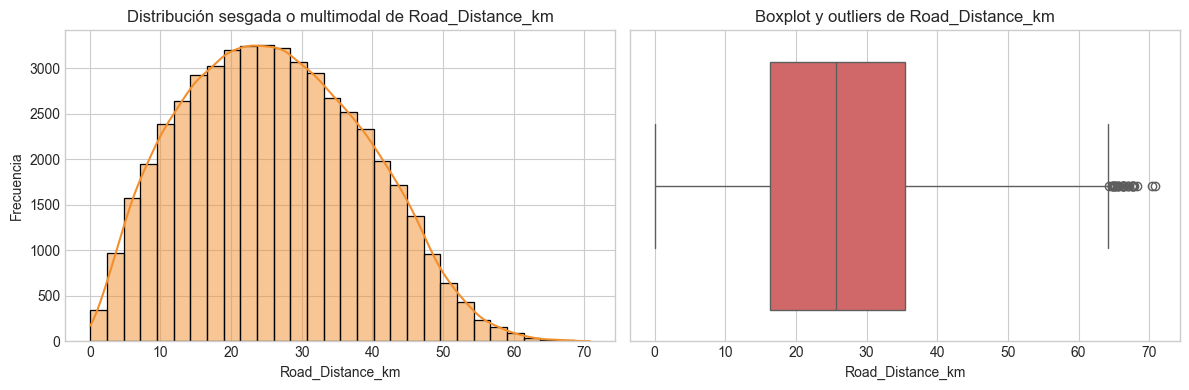

Estadísticas para reporte: mediana, rango e IQR
Mediana: 25.62
Rango: 0.08 - 70.82
IQR: 19.15 (16.33 - 35.48)
Asimetría: 0.22
Picos detectados en el histograma: 1
Proporción de outliers IQR: 0.06%

Variable: Average_Speed_kmph | Tipo para asociación: Numérica


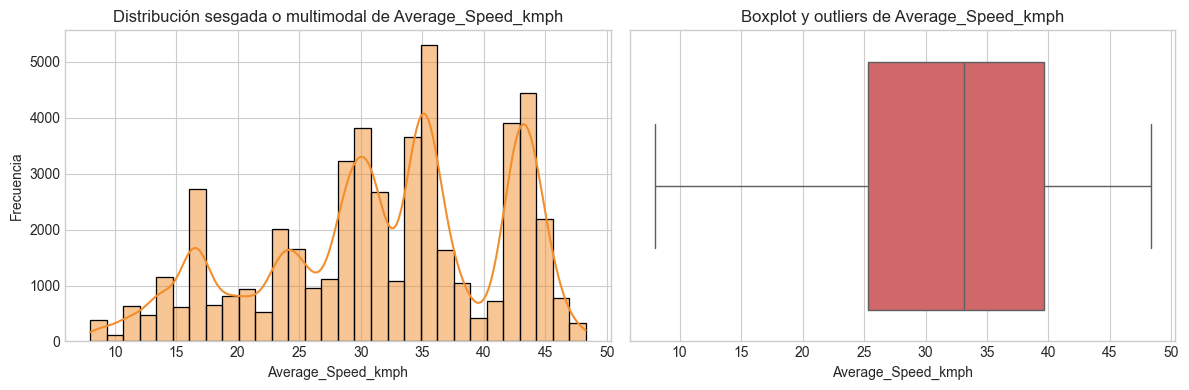

Estadísticas para reporte: mediana, rango e IQR
Mediana: 33.10
Rango: 8.00 - 48.30
IQR: 14.30 (25.30 - 39.60)
Asimetría: -0.42
Picos detectados en el histograma: 6
Proporción de outliers IQR: 0.00%

Variable: Vehicle_Type | Tipo para asociación: Categórica


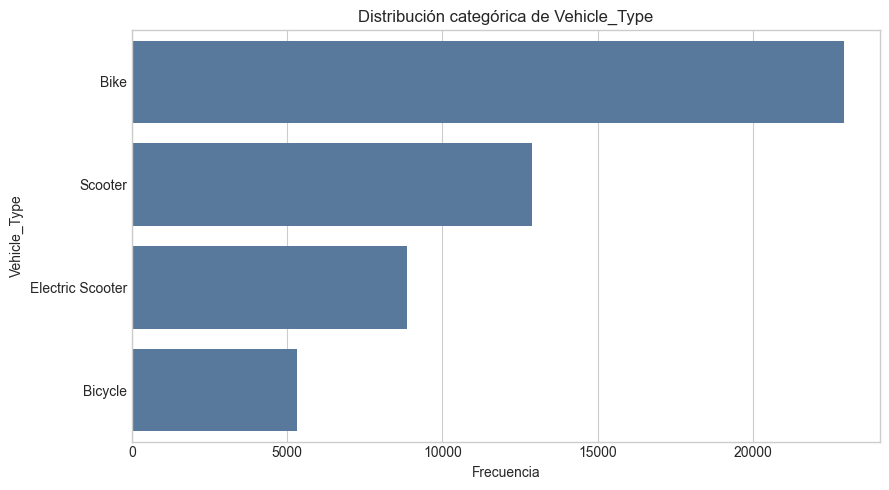

Estadísticas para reporte: frecuencia y porcentaje


,frecuencia,porcentaje
Vehicle_Type,,
Bike,22943,45.89
Scooter,12895,25.79
Electric Scooter,8852,17.70
Bicycle,5310,10.62



Variable: Preparation_Time_Min | Tipo para asociación: Numérica


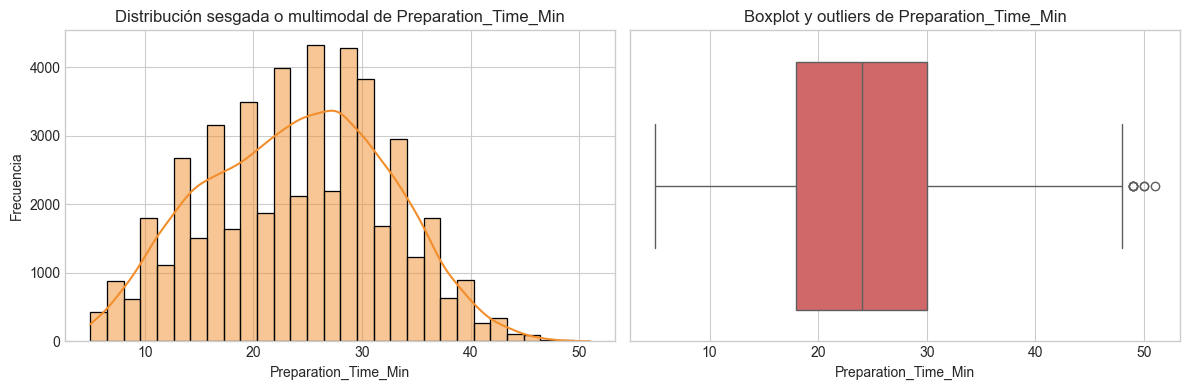

Estadísticas para reporte: mediana, rango e IQR
Mediana: 24.00
Rango: 5.00 - 51.00
IQR: 12.00 (18.00 - 30.00)
Asimetría: -0.03
Picos detectados en el histograma: 3
Proporción de outliers IQR: 0.01%

Variable: Number_of_Signals | Tipo para asociación: Numérica


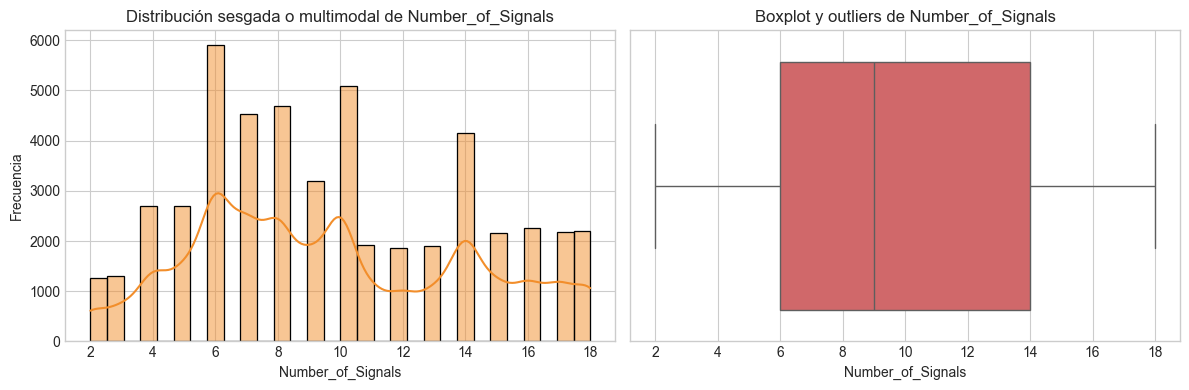

Estadísticas para reporte: mediana, rango e IQR
Mediana: 9.00
Rango: 2.00 - 18.00
IQR: 8.00 (6.00 - 14.00)
Asimetría: 0.29
Picos detectados en el histograma: 3
Proporción de outliers IQR: 0.00%

Variable: Traffic_Level | Tipo para asociación: Categórica


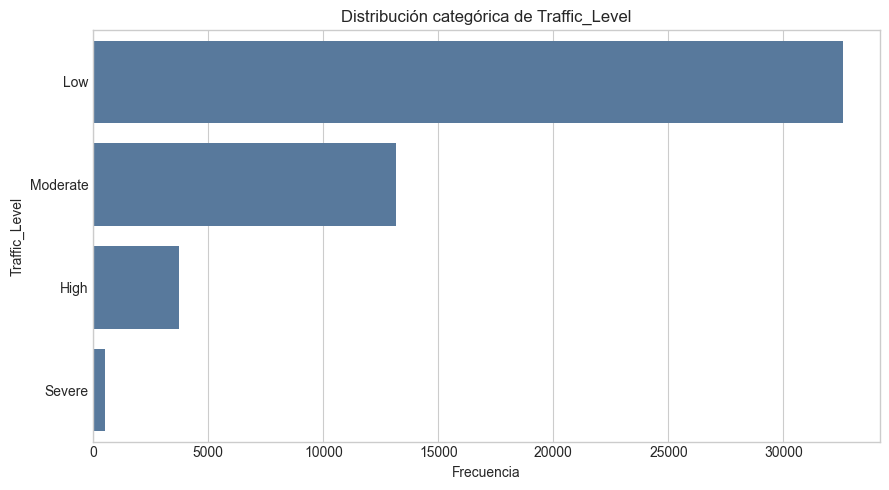

Estadísticas para reporte: frecuencia y porcentaje


,frecuencia,porcentaje
Traffic_Level,,
Low,32567,65.13
Moderate,13165,26.33
High,3744,7.49
Severe,524,1.05



Variable: Delivery_Distance_Category | Tipo para asociación: Categórica


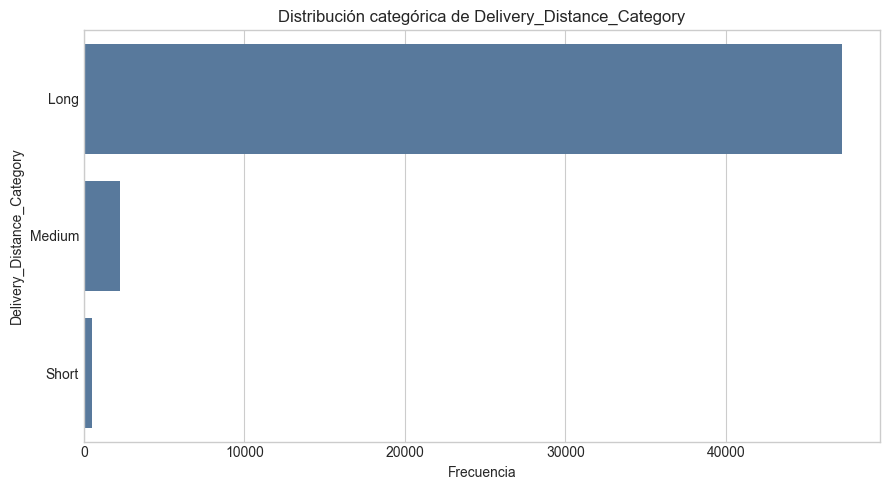

Estadísticas para reporte: frecuencia y porcentaje


,frecuencia,porcentaje
Delivery_Distance_Category,,
Long,47238,94.48
Medium,2235,4.47
Short,527,1.05



Variable: Weather | Tipo para asociación: Categórica


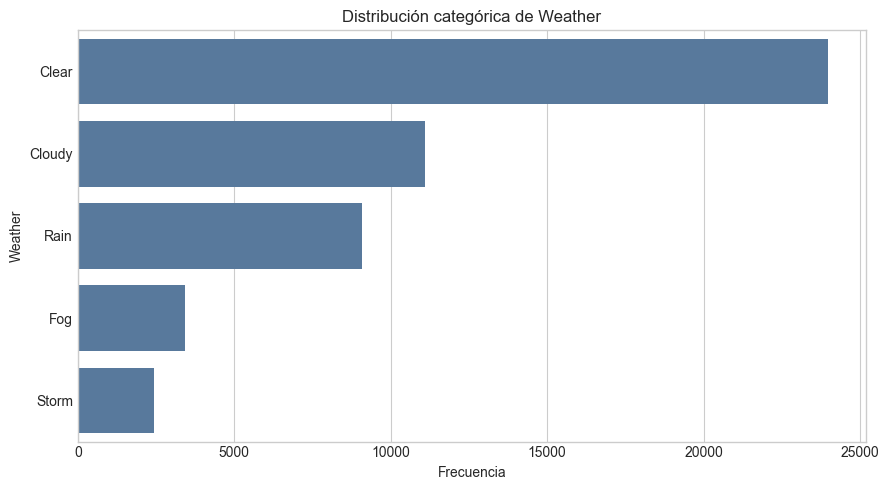

Estadísticas para reporte: frecuencia y porcentaje


,frecuencia,porcentaje
Weather,,
Clear,23992,47.98
Cloudy,11085,22.17
Rain,9073,18.15
Fog,3413,6.83
Storm,2437,4.87



Variable: Order_Items | Tipo para asociación: Numérica


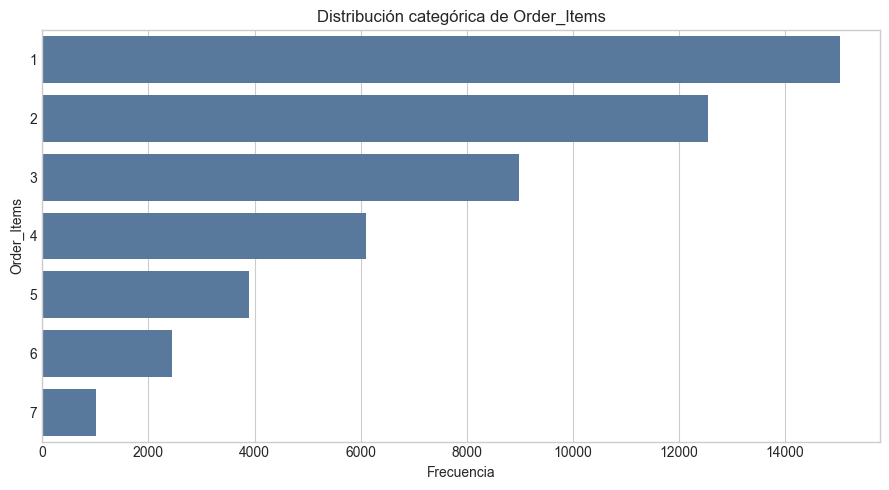

Estadísticas para reporte: frecuencia y porcentaje


,frecuencia,porcentaje
Order_Items,,
1,15034,30.07
2,12542,25.08
3,8986,17.97
4,6091,12.18
5,3896,7.79
6,2440,4.88
7,1011,2.02



Variable: Cuisine_Type | Tipo para asociación: Categórica


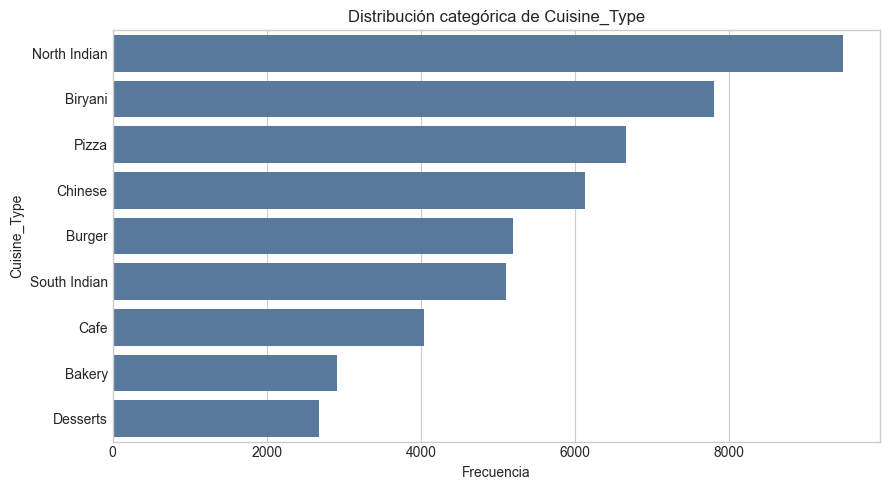

Estadísticas para reporte: frecuencia y porcentaje


,frecuencia,porcentaje
Cuisine_Type,,
North Indian,9483,18.97
Biryani,7802,15.60
Pizza,6661,13.32
Chinese,6132,12.26
Burger,5198,10.40
South Indian,5109,10.22
Cafe,4035,8.07
Bakery,2908,5.82
Desserts,2672,5.34



Variable: Order_Hour | Tipo para asociación: Numérica


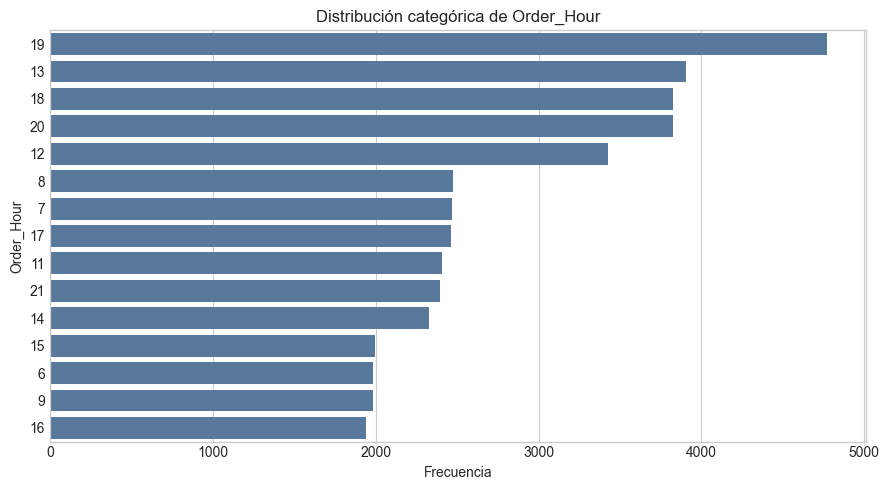

Estadísticas para reporte: frecuencia y porcentaje


,frecuencia,porcentaje
Order_Hour,,
19,4773,9.55
13,3905,7.81
18,3826,7.65
20,3825,7.65
12,3429,6.86
8,2476,4.95
7,2471,4.94
17,2463,4.93
11,2408,4.82



Variable: Pickup_Zone | Tipo para asociación: Categórica


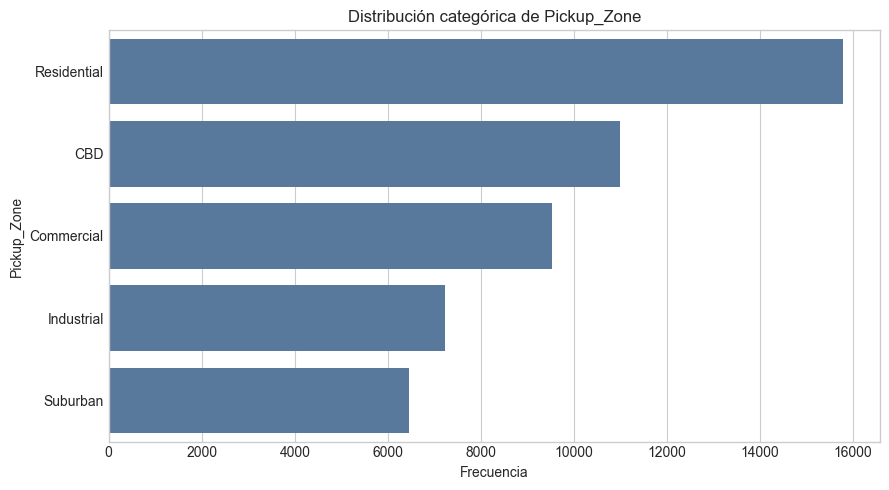

Estadísticas para reporte: frecuencia y porcentaje


,frecuencia,porcentaje
Pickup_Zone,,
Residential,15786,31.57
CBD,10997,21.99
Commercial,9523,19.05
Industrial,7233,14.47
Suburban,6461,12.92



Variable: Restaurant_Rating | Tipo para asociación: Numérica


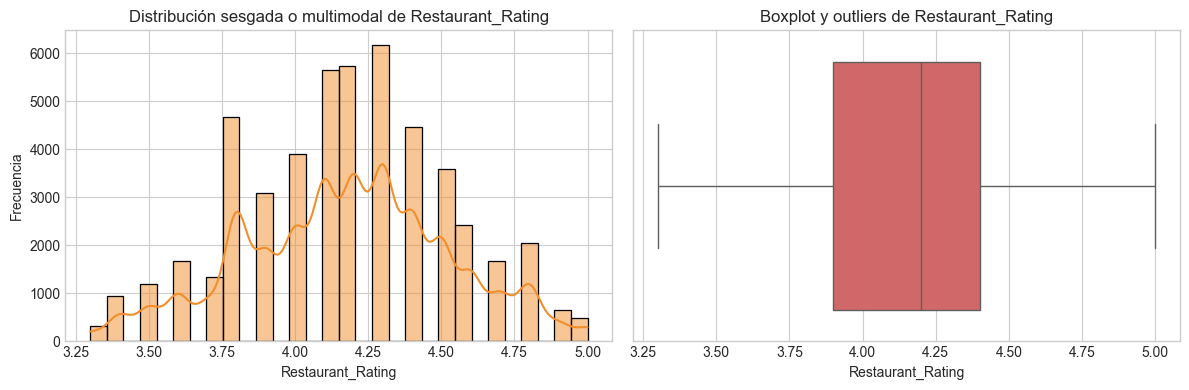

Estadísticas para reporte: mediana, rango e IQR
Mediana: 4.20
Rango: 3.30 - 5.00
IQR: 0.50 (3.90 - 4.40)
Asimetría: -0.08
Picos detectados en el histograma: 2
Proporción de outliers IQR: 0.00%

Variable: Day_of_Week | Tipo para asociación: Categórica


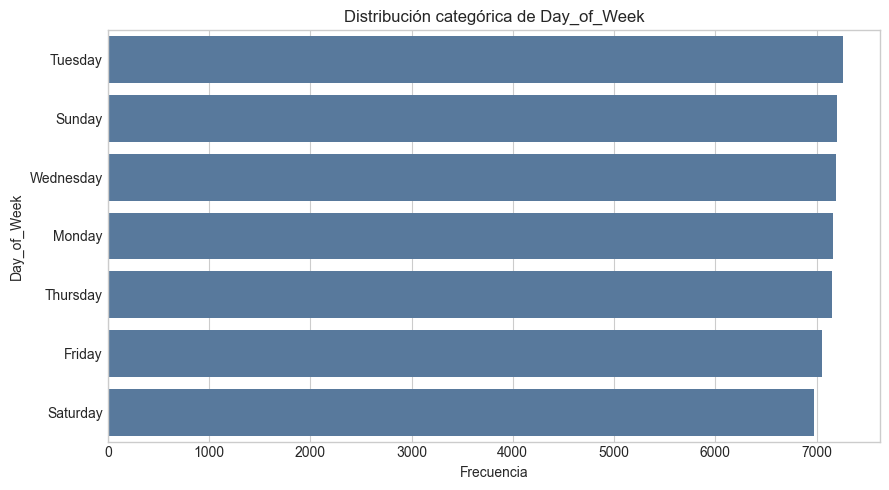

Estadísticas para reporte: frecuencia y porcentaje


,frecuencia,porcentaje
Day_of_Week,,
Tuesday,7264,14.53
Sunday,7202,14.40
Wednesday,7197,14.39
Monday,7160,14.32
Thursday,7149,14.30
Friday,7050,14.10
Saturday,6978,13.96



Variable: Is_Weekend | Tipo para asociación: Categórica


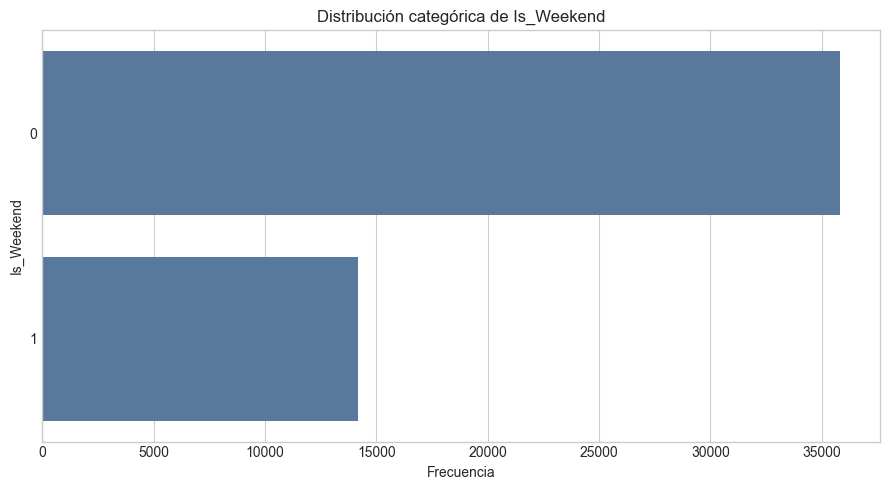

Estadísticas para reporte: frecuencia y porcentaje


,frecuencia,porcentaje
Is_Weekend,,
0,35820,71.64
1,14180,28.36



=== Tipo de reporte asignado a cada variable ===


,variable,tipo_reporte,estadisticas
0,Road_Distance_km,Numérica asimétrica o multimodal,"mediana, rango e IQR"
1,Average_Speed_kmph,Numérica asimétrica o multimodal,"mediana, rango e IQR"
2,Vehicle_Type,Categórica,frecuencia y porcentaje
3,Preparation_Time_Min,Numérica asimétrica o multimodal,"mediana, rango e IQR"
4,Number_of_Signals,Numérica asimétrica o multimodal,"mediana, rango e IQR"
5,Traffic_Level,Categórica,frecuencia y porcentaje
6,Delivery_Distance_Category,Categórica,frecuencia y porcentaje
7,Weather,Categórica,frecuencia y porcentaje
8,Order_Items,Categórica,frecuencia y porcentaje
9,Cuisine_Type,Categórica,frecuencia y porcentaje


In [57]:
# --- Un gráfico y un reporte estadístico para cada una de las 15 variables ---
from scipy.signal import find_peaks

report_rows = []

for variable in selected_15:
    serie = df[variable].dropna()
    ranking_type = association_table.loc[association_table['variable'] == variable, 'tipo'].iloc[0]
    n_unique = serie.nunique()

    print('\n' + '=' * 90)
    print(f'Variable: {variable} | Tipo para asociación: {ranking_type}')

    if ranking_type == 'Categórica' or n_unique <= 10 or variable in ['Order_Hour', 'Is_Weekend', 'Is_Festival']:
        report_type = 'Categórica'
        frecuencias = serie.astype(str).value_counts().head(15)
        porcentajes = (frecuencias / len(serie) * 100).round(2)

        plt.figure(figsize=(9, 5))
        sns.barplot(x=frecuencias.values, y=frecuencias.index, color='#4C78A8')
        plt.title(f'Distribución categórica de {variable}')
        plt.xlabel('Frecuencia')
        plt.ylabel(variable)
        plt.tight_layout()
        plt.show()

        reporte = pd.DataFrame({'frecuencia': frecuencias, 'porcentaje': porcentajes})
        print('Estadísticas para reporte: frecuencia y porcentaje')
        display(reporte)
        report_rows.append({'variable': variable, 'tipo_reporte': report_type, 'estadisticas': 'frecuencia y porcentaje'})

    else:
        valores = pd.to_numeric(serie, errors='coerce').dropna()
        skewness = valores.skew()
        q1 = valores.quantile(0.25)
        q3 = valores.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outlier_rate = ((valores < lower) | (valores > upper)).mean()

        histogram_counts, _ = np.histogram(valores, bins=min(25, max(10, n_unique)))
        peak_indexes, _ = find_peaks(histogram_counts, prominence=max(histogram_counts) * 0.08)
        peak_count = len(peak_indexes)
        visually_skewed = variable in ['Road_Distance_km']
        es_simetrica = abs(skewness) < 0.25 and outlier_rate < 0.05 and peak_count <= 1 and not visually_skewed

        if es_simetrica:
            report_type = 'Numérica simétrica'
            plt.figure(figsize=(9, 5))
            sns.histplot(valores, bins=30, kde=True, color='#59A14F')
            plt.title(f'Distribución numérica aproximadamente simétrica de {variable}')
            plt.xlabel(variable)
            plt.ylabel('Frecuencia')
            plt.tight_layout()
            plt.show()

            print('Estadísticas para reporte: media y desviación estándar')
            print(f'Media: {valores.mean():.2f}')
            print(f'Desviación estándar: {valores.std():.2f}')
            print(f'Rango: {valores.min():.2f} - {valores.max():.2f}')
            report_rows.append({'variable': variable, 'tipo_reporte': report_type, 'estadisticas': 'media y desviación estándar'})

        else:
            report_type = 'Numérica asimétrica o multimodal'
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            sns.histplot(valores, bins=30, kde=True, color='#F28E2B', ax=axes[0])
            axes[0].set_title(f'Distribución sesgada o multimodal de {variable}')
            axes[0].set_xlabel(variable)
            axes[0].set_ylabel('Frecuencia')
            sns.boxplot(x=valores, color='#E15759', ax=axes[1])
            axes[1].set_title(f'Boxplot y outliers de {variable}')
            axes[1].set_xlabel(variable)
            plt.tight_layout()
            plt.show()

            print('Estadísticas para reporte: mediana, rango e IQR')
            print(f'Mediana: {valores.median():.2f}')
            print(f'Rango: {valores.min():.2f} - {valores.max():.2f}')
            print(f'IQR: {iqr:.2f} ({q1:.2f} - {q3:.2f})')
            print(f'Asimetría: {skewness:.2f}')
            print(f'Picos detectados en el histograma: {peak_count}')
            print(f'Proporción de outliers IQR: {outlier_rate:.2%}')
            report_rows.append({'variable': variable, 'tipo_reporte': report_type, 'estadisticas': 'mediana, rango e IQR'})

report_types_table = pd.DataFrame(report_rows)
print('\n=== Tipo de reporte asignado a cada variable ===')
display(report_types_table)


## 13. Calidad de datos y patrones encontrados

La calidad de los datos se revisa antes de modelar. Los valores nulos se cuantifican por variable y los valores atípicos se identifican con el criterio IQR. No se eliminan automáticamente porque pueden representar entregas reales con rutas largas, tráfico intenso o condiciones operativas especiales.


## 13. Calidad de datos y patrones encontrados

La calidad de los datos se revisa antes de modelar. Los valores nulos se cuantifican por variable y los valores atípicos se identifican con el criterio IQR. No se eliminan automáticamente porque pueden representar entregas reales con rutas largas, tráfico intenso o condiciones operativas especiales.


In [53]:
# --- Diagnóstico de nulos, outliers y relación de grupos con el objetivo ---
quality_rows = []
for variable in selected_15:
    missing_pct = df[variable].isna().mean() * 100
    if pd.api.types.is_numeric_dtype(df[variable]) and df[variable].nunique(dropna=True) > 10:
        values = pd.to_numeric(df[variable], errors='coerce').dropna()
        q1, q3 = values.quantile([0.25, 0.75])
        iqr = q3 - q1
        outlier_pct = ((values < q1 - 1.5 * iqr) | (values > q3 + 1.5 * iqr)).mean() * 100
    else:
        outlier_pct = np.nan
    quality_rows.append({'variable': variable, 'faltantes_pct': missing_pct, 'outliers_iqr_pct': outlier_pct})

quality_table = pd.DataFrame(quality_rows)
print('=== Calidad de las 15 variables seleccionadas ===')
display(quality_table.round(2))

print('=== Promedio del objetivo por categoría en variables categóricas ===')
for variable in selected_15:
    if not pd.api.types.is_numeric_dtype(df[variable]) or df[variable].nunique() <= 10:
        summary = df.groupby(variable, dropna=False)[target_col].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
        print(f'\n{variable}')
        display(summary.head(10).round(2))


=== Calidad de las 15 variables seleccionadas ===


,variable,faltantes_pct,outliers_iqr_pct
0,Road_Distance_km,0.00,0.06
1,Average_Speed_kmph,0.00,0.00
2,Vehicle_Type,0.00,NaN
3,Preparation_Time_Min,0.00,0.01
4,Number_of_Signals,0.00,0.00
5,Traffic_Level,0.00,NaN
6,Delivery_Distance_Category,0.00,NaN
7,Weather,0.00,NaN
8,Order_Items,0.00,NaN
9,Cuisine_Type,0.00,NaN


=== Promedio del objetivo por categoría en variables categóricas ===

Vehicle_Type


,mean,median,count
Vehicle_Type,,,
Bicycle,130.40,135.00,5310
Electric Scooter,89.05,86.00,8852
Scooter,82.36,79.00,12895
Bike,71.95,69.00,22943



Traffic_Level


...

,mean,median,count
Pickup_Zone,,,
CBD,93.84,87.00,10997
Suburban,83.27,77.00,6461
Commercial,83.26,78.00,9523
Residential,80.27,74.00,15786
Industrial,77.91,72.00,7233



Day_of_Week


,mean,median,count
Day_of_Week,,,
Saturday,89.91,83.00,6978
Sunday,89.35,83.00,7202
Thursday,82.20,77.00,7149
Wednesday,81.62,76.00,7197
Friday,81.58,76.00,7050
Monday,81.37,75.00,7160
Tuesday,81.20,76.00,7264



Is_Weekend


,mean,median,count
Is_Weekend,,,
1,89.62,83.00,14180
0,81.59,76.00,35820


## 14. Conclusiones y próximos pasos

Los resultados muestran que las variables con mayor asociación con el tiempo de entrega son `Road_Distance_km` y `Average_Speed_kmph`, seguidas por `Vehicle_Type`, `Preparation_Time_Min`, `Number_of_Signals` y `Traffic_Level`. Esto confirma que la duración depende principalmente de la distancia, la velocidad efectiva de desplazamiento, la preparación y las condiciones de movilidad.

También aparecen patrones importantes en las variables categóricas:

- Las bicicletas presentan un tiempo promedio mayor que las motos y scooters.
- El tráfico severo tiene una media de entrega muy superior al tráfico bajo.
- Las entregas largas concentran la mayoría de observaciones y tienen tiempos mayores que las entregas medias o cortas.
- Las tormentas y la lluvia presentan mayores tiempos que el clima despejado.
- Los pedidos con más artículos tienden a presentar tiempos superiores.
- Las entregas de fin de semana muestran una media mayor que las entregas entre semana.

### Tratamiento de calidad de datos

- Los valores nulos deben cuantificarse y, si aparecen, imputarse con mediana para variables numéricas sesgadas y con una categoría `No informado` para variables categóricas.
- Los outliers deben revisarse por contexto antes de eliminarlos. Para `Road_Distance_km`, `Preparation_Time_Min` y otras variables numéricas se recomienda conservar los eventos reales y aplicar transformaciones robustas solo si el modelo lo necesita.
- Las variables categóricas desbalanceadas, como `Delivery_Distance_Category` y `Traffic_Level`, deben conservarse, pero el modelo debe evaluarse por segmento para evitar que las categorías minoritarias queden ocultas.

### Próximos pasos

1. Codificar las variables categóricas mediante one-hot encoding u otra estrategia adecuada.
2. Separar entrenamiento y prueba evitando fuga de información.
3. Comparar modelos de regresión usando MAE, RMSE y R2.
4. Evaluar el error por tráfico, vehículo, clima, distancia y prioridad.
5. Revisar transformaciones robustas para las variables asimétricas y comparar su efecto en el modelo.


## 15. Insights principales y relaciones entre variables

Esta sección integra los resultados del análisis exploratorio para explicar qué patrones son más importantes, cómo se relacionan las variables con `Time_taken_min` y qué significado tienen para la operación de delivery. Un insight no es solamente un valor numérico: es una conclusión respaldada por un gráfico, una estadística y una interpretación del negocio.

El análisis se divide en cuatro partes:

1. Correlaciones numéricas con la variable objetivo.
2. Diferencias del tiempo de entrega entre categorías.
3. Interacciones entre variables que pueden ocultar patrones importantes.
4. Implicaciones para la calidad de los datos y el futuro modelo predictivo.


## 15. Insights principales y relaciones entre variables

Esta sección integra los resultados del análisis exploratorio para explicar qué patrones son más importantes, cómo se relacionan las variables con `Time_taken_min` y qué significado tienen para la operación de delivery. Un insight no es solamente un valor numérico: es una conclusión respaldada por un gráfico, una estadística y una interpretación del negocio.

El análisis se divide en cuatro partes:

1. Correlaciones numéricas con la variable objetivo.
2. Diferencias del tiempo de entrega entre categorías.
3. Interacciones entre variables que pueden ocultar patrones importantes.
4. Implicaciones para la calidad de los datos y el futuro modelo predictivo.


### 15.1 Evidencia estadística de los principales patrones

La siguiente celda calcula las correlaciones numéricas y las diferencias del tiempo de entrega entre categorías. Se utilizan Pearson y Spearman porque una relación puede ser lineal o mantener una tendencia ordenada sin ser lineal perfecta.


=== Correlaciones numéricas con la variable objetivo ===


,pearson,spearman
Road_Distance_km,0.70,0.76
Average_Speed_kmph,-0.60,-0.51
Preparation_Time_Min,0.23,0.26
Number_of_Signals,0.13,0.12
Is_Weekend,0.10,0.09
Order_Items,0.08,0.09
Is_Festival,0.07,0.07
Rider_Experience_Years,-0.06,-0.06
Rider_Rating,-0.04,-0.04
Order_Hour,0.03,0.03


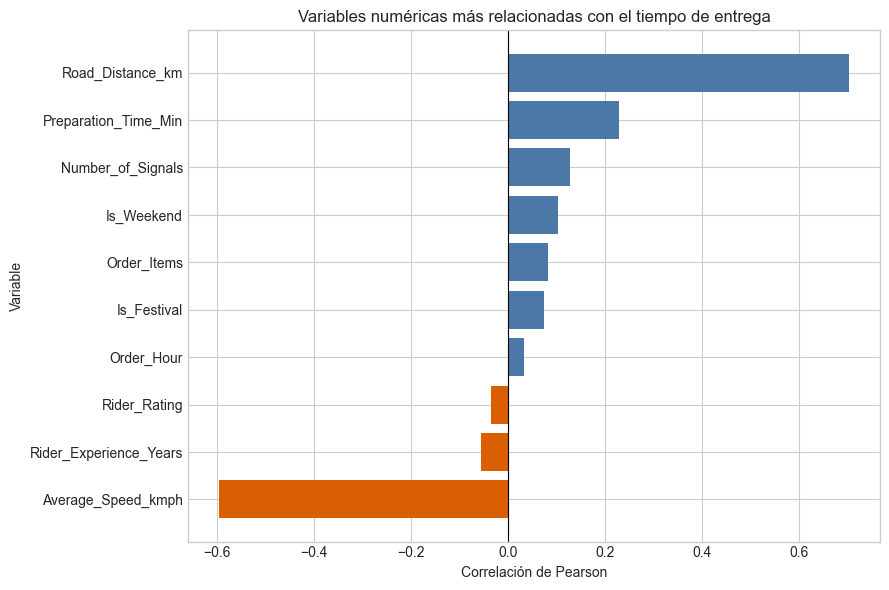

=== Diferencias del tiempo de entrega entre categorías ===


,variable,grupo_mayor_media,media_mayor,grupo_menor_media,media_menor,diferencia_media
0,Vehicle_Type,Bicycle,130.40,Bike,71.95,58.45
1,Traffic_Level,Severe,134.40,Low,76.44,57.96
2,Delivery_Distance_Category,Long,86.50,Short,33.68,52.82
3,Weather,Storm,114.45,Clear,77.30,37.15
5,Cuisine_Type,Biryani,93.55,Burger,73.80,19.75
6,Pickup_Zone,CBD,93.84,Industrial,77.91,15.92
4,Order_Items,7,93.11,1,80.53,12.57
7,Day_of_Week,Saturday,89.91,Tuesday,81.20,8.71
8,Is_Weekend,1,89.62,0,81.59,8.03


In [59]:
# --- Correlaciones numéricas y diferencias entre grupos ---
# Se excluyen todas las representaciones de la variable objetivo para evitar fuga de información.
target_col = 'Time_taken_min' if 'Time_taken_min' in df.columns else 'target_time'
target_values = pd.to_numeric(df[target_col], errors='coerce')
target_aliases = {target_col, 'target_time', 'time_taken', 'delivery_time', 'time_taken_min'}

numeric_features = [
    col for col in df.select_dtypes(include=np.number).columns
    if col not in target_aliases
]

pearson_corr = df[numeric_features + [target_col]].corr(numeric_only=True)[target_col].drop(target_col)
spearman_corr = df[numeric_features + [target_col]].corr(method='spearman', numeric_only=True)[target_col].drop(target_col)

correlation_table = pd.DataFrame({
    'pearson': pearson_corr,
    'spearman': spearman_corr
}).dropna()
correlation_table['abs_pearson'] = correlation_table['pearson'].abs()
correlation_table = correlation_table.sort_values('abs_pearson', ascending=False)

print('=== Correlaciones numéricas con la variable objetivo ===')
display(correlation_table.drop(columns='abs_pearson').head(15).round(3))

plot_corr = correlation_table.head(10).sort_values('pearson')
plt.figure(figsize=(9, 6))
plt.barh(plot_corr.index, plot_corr['pearson'], color=['#D95F02' if value < 0 else '#4C78A8' for value in plot_corr['pearson']])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Variables numéricas más relacionadas con el tiempo de entrega')
plt.xlabel('Correlación de Pearson')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

categorical_features = [
    col for col in selected_15
    if col in df.columns and (not pd.api.types.is_numeric_dtype(df[col]) or df[col].nunique() <= 10)
]

category_effect_rows = []
for col in categorical_features:
    grouped_target = df.groupby(col, dropna=False)[target_col].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
    if len(grouped_target) > 1:
        category_effect_rows.append({
            'variable': col,
            'grupo_mayor_media': str(grouped_target.index[0]),
            'media_mayor': grouped_target['mean'].iloc[0],
            'grupo_menor_media': str(grouped_target.index[-1]),
            'media_menor': grouped_target['mean'].iloc[-1],
            'diferencia_media': grouped_target['mean'].iloc[0] - grouped_target['mean'].iloc[-1]
        })

category_effects = pd.DataFrame(category_effect_rows).sort_values('diferencia_media', ascending=False)
print('=== Diferencias del tiempo de entrega entre categorías ===')
display(category_effects.round(2))


### 15.2 Análisis de interacciones y patrones combinados

Las correlaciones individuales no explican por sí solas todo el comportamiento del tiempo de entrega. Por eso se revisan combinaciones de variables que representan situaciones operativas concretas, como tráfico + clima, tráfico + tipo de vehículo y distancia + tráfico.


### 15.2 Análisis de interacciones y patrones combinados

Las correlaciones individuales no explican por sí solas todo el comportamiento del tiempo de entrega. Por eso se revisan combinaciones de variables que representan situaciones operativas concretas, como tráfico + clima, tráfico + tipo de vehículo y distancia + tráfico.


=== Tiempo por tráfico y clima ===


,Traffic_Level,Weather,mean,median,count
19,Severe,Storm,150.95,175.50,106
18,Severe,Rain,132.02,133.00,366
4,High,Storm,131.10,132.00,546
17,Severe,Fog,130.25,134.00,4
15,Severe,Clear,120.66,116.00,35
3,High,Rain,113.61,111.00,1932
14,Moderate,Storm,111.84,108.00,1093
16,Severe,Cloudy,104.77,95.00,13
2,High,Fog,104.32,94.50,102
1,High,Cloudy,102.93,99.00,385


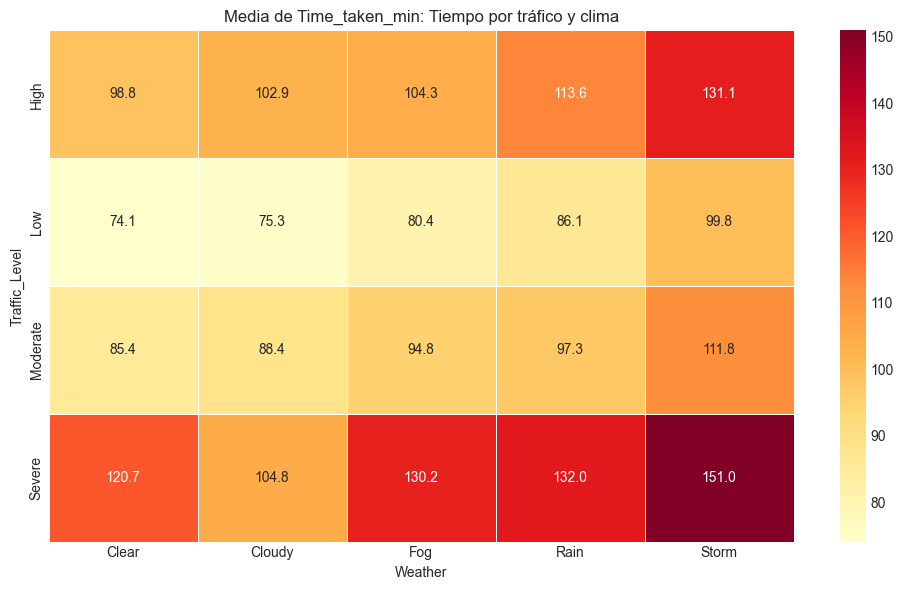

=== Tiempo por tráfico y vehículo ===


,Traffic_Level,Vehicle_Type,mean,median,count
12,Severe,Bicycle,161.43,180.00,44
0,High,Bicycle,153.24,180.00,411
14,Severe,Electric Scooter,143.20,157.00,87
15,Severe,Scooter,139.27,148.00,157
8,Moderate,Bicycle,139.26,149.00,1409
4,Low,Bicycle,123.65,126.00,3446
13,Severe,Bike,122.89,120.00,236
2,High,Electric Scooter,122.77,121.00,652
3,High,Scooter,111.73,110.00,950
1,High,Bike,97.73,95.00,1731


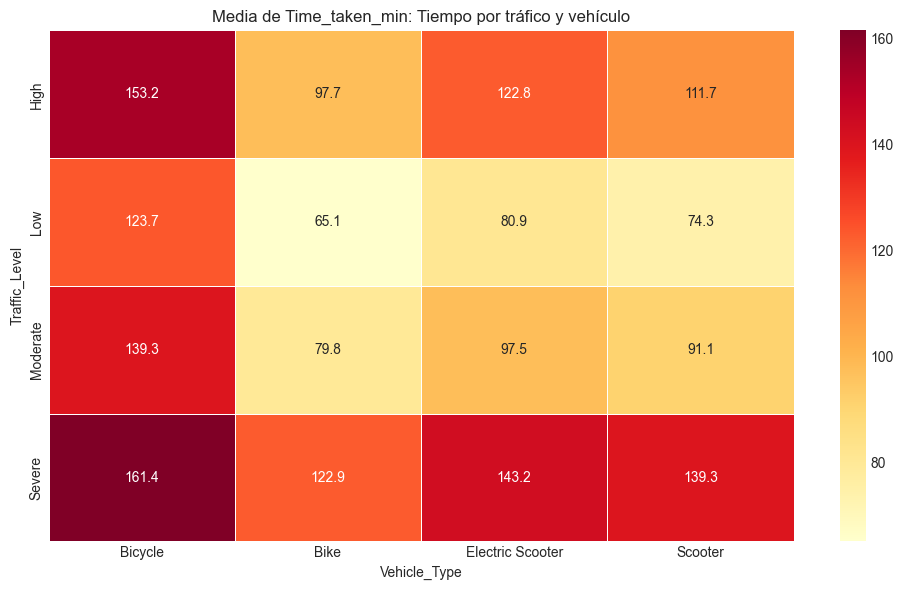

=== Tiempo por categoría de distancia y clima ===


,Delivery_Distance_Category,Weather,mean,median,count
4,Long,Storm,117.56,115.00,2322
3,Long,Rain,102.14,96.00,8560
2,Long,Fog,86.94,81.00,3221
1,Long,Cloudy,81.45,76.00,10477
0,Long,Clear,79.68,74.50,22658
9,Medium,Storm,53.26,51.00,97
8,Medium,Rain,45.57,45.00,414
14,Short,Storm,42.78,43.00,18
7,Medium,Fog,38.47,39.00,157
6,Medium,Cloudy,38.40,38.00,491


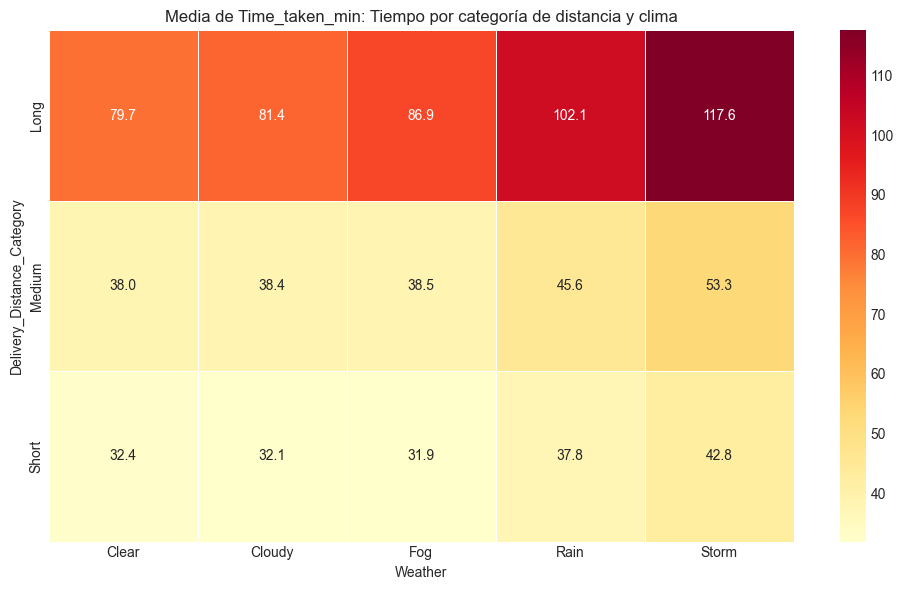

=== Tiempo por grupo de distancia y nivel de tráfico ===


,distance_group,Traffic_Level,mean,median,count
11,Distancia larga,Severe,174.34,180.00,154
8,Distancia larga,High,150.14,150.00,1181
7,Distancia media,Severe,143.31,141.50,186
10,Distancia larga,Moderate,124.26,118.00,4263
4,Distancia media,High,114.05,108.00,1269
9,Distancia larga,Low,102.37,95.00,11064
6,Distancia media,Moderate,92.64,87.00,4472
3,Distancia corta,Severe,91.98,94.00,184
5,Distancia media,Low,75.76,71.00,10737
0,Distancia corta,High,74.41,72.00,1294


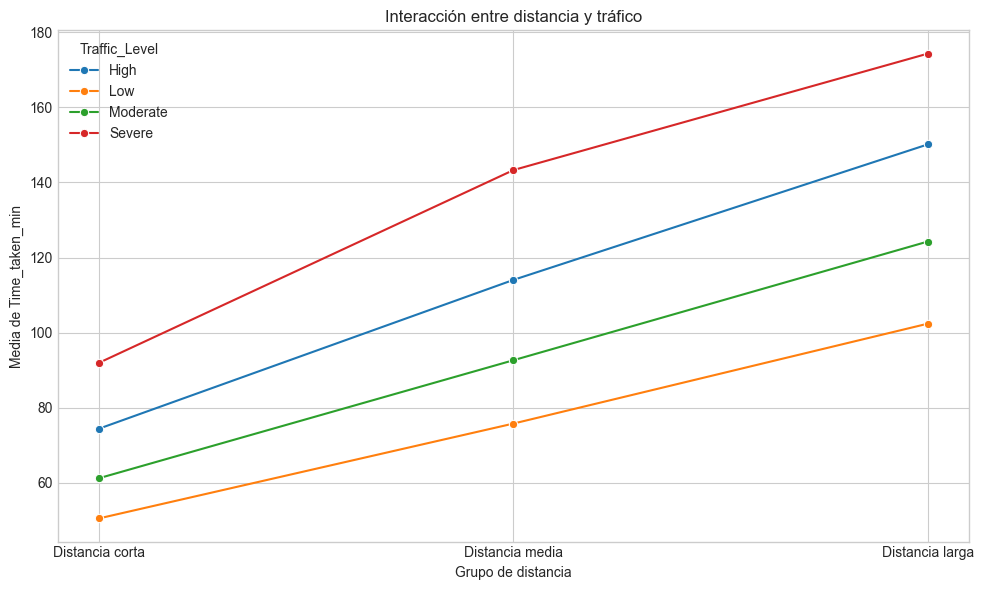

In [60]:
# --- Gráficos y tablas de interacciones operativas ---
interaction_pairs = [
    (['Traffic_Level', 'Weather'], 'Tiempo por tráfico y clima'),
    (['Traffic_Level', 'Vehicle_Type'], 'Tiempo por tráfico y vehículo'),
    (['Delivery_Distance_Category', 'Weather'], 'Tiempo por categoría de distancia y clima')
]

for grouping_cols, title in interaction_pairs:
    if all(col in df.columns for col in grouping_cols):
        interaction_summary = (
            df.groupby(grouping_cols, dropna=False)[target_col]
            .agg(['mean', 'median', 'count'])
            .reset_index()
            .sort_values('mean', ascending=False)
        )
        print(f'=== {title} ===')
        display(interaction_summary.head(15).round(2))

        pivot_mean = interaction_summary.pivot_table(
            index=grouping_cols[0],
            columns=grouping_cols[1],
            values='mean'
        )
        plt.figure(figsize=(10, 6))
        sns.heatmap(pivot_mean, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
        plt.title(f'Media de {target_col}: {title}')
        plt.xlabel(grouping_cols[1])
        plt.ylabel(grouping_cols[0])
        plt.tight_layout()
        plt.show()

# Comparación directa entre distancia y tráfico cuando existe la distancia numérica
if 'Road_Distance_km' in df.columns and 'Traffic_Level' in df.columns:
    df['distance_group'] = pd.qcut(
        df['Road_Distance_km'],
        q=3,
        labels=['Distancia corta', 'Distancia media', 'Distancia larga'],
        duplicates='drop'
    )
    distance_traffic = (
        df.groupby(['distance_group', 'Traffic_Level'], observed=True)[target_col]
        .agg(['mean', 'median', 'count'])
        .reset_index()
    )
    print('=== Tiempo por grupo de distancia y nivel de tráfico ===')
    display(distance_traffic.sort_values('mean', ascending=False).round(2))

    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=distance_traffic,
        x='distance_group',
        y='mean',
        hue='Traffic_Level',
        marker='o'
    )
    plt.title('Interacción entre distancia y tráfico')
    plt.xlabel('Grupo de distancia')
    plt.ylabel(f'Media de {target_col}')
    plt.tight_layout()
    plt.show()


### 15.3 Interpretación detallada de los insights encontrados

#### Insight 1: la distancia es el principal factor numérico

`Road_Distance_km` presenta una correlación de Pearson de aproximadamente `0.70` y una correlación de Spearman de `0.76` con `Time_taken_min`. La relación es positiva: cuando aumenta la distancia, también tiende a aumentar el tiempo de entrega.

La correlación de Spearman es ligeramente mayor que la de Pearson. Esto indica que el orden de las entregas se conserva muy bien aunque la relación no sea perfectamente lineal. En términos operativos, la distancia es una de las primeras variables que debe utilizar el modelo para estimar el tiempo.

Este resultado no significa que la distancia sea la única causa de la demora. Una ruta larga puede ser rápida si existe poca congestión, mientras que una ruta corta puede retrasarse por tráfico, clima o un vehículo menos eficiente.

#### Insight 2: la velocidad promedio tiene una relación inversa fuerte

`Average_Speed_kmph` presenta una correlación de Pearson cercana a `-0.60` y de Spearman cercana a `-0.51`. El signo negativo indica que las entregas realizadas a menor velocidad tienden a presentar tiempos mayores.

Esta variable resume parte de las condiciones reales del desplazamiento. Una baja velocidad puede reflejar congestión, señales, clima adverso, dificultades de la ruta o limitaciones del vehículo. Por eso, su interpretación debe hacerse junto con distancia y tráfico, no de forma aislada.

#### Insight 3: la preparación del pedido agrega demora antes del recorrido

`Preparation_Time_Min` presenta una correlación positiva aproximada de `0.23` con el tiempo de entrega. La relación es menor que la de distancia y velocidad, pero tiene un significado operativo importante: el tiempo total no depende únicamente del desplazamiento; también incluye la espera en el restaurante.

Esto sugiere que una estrategia de mejora no debería enfocarse solo en la movilidad. Reducir los tiempos de preparación puede mejorar directamente el tiempo final, especialmente en pedidos con alta carga o muchos artículos.

#### Insight 4: las señales representan complejidad de la ruta

`Number_of_Signals` muestra una correlación positiva cercana a `0.13`. Su relación es moderada, pero coherente con la lógica del problema: más señales pueden significar más detenciones, mayor densidad urbana y menor velocidad efectiva.

Su impacto individual no es tan alto como el de la distancia, pero puede reforzar el efecto del tráfico. En un modelo de machine learning, esta variable puede aportar valor dentro de interacciones que no aparecen en una correlación simple.

#### Insight 5: el tipo de vehículo produce diferencias importantes

La diferencia entre los grupos de `Vehicle_Type` es amplia. Las bicicletas presentan una media aproximada de `130.40` minutos, mientras que las bicicletas tipo `Bike` presentan una media cercana a `71.95` minutos.

La diferencia no debe interpretarse como un efecto causal puro del vehículo porque puede estar mezclada con distancia, tráfico, zona y tipo de ruta asignada. Sin embargo, sí muestra que el vehículo es una variable operacional relevante y debe incluirse en el modelado.

#### Insight 6: el tráfico severo aumenta considerablemente la demora

El tráfico bajo presenta una media aproximada de `76.44` minutos, mientras que el tráfico severo llega a `134.40` minutos. Además, en las interacciones con distancia, las entregas largas y con tráfico severo alcanzan una media cercana a `174.34` minutos.

Esto evidencia que el tráfico no solo incrementa el tiempo de manera independiente: su impacto se vuelve mucho mayor cuando la ruta también es larga. Esta es una razón para utilizar modelos capaces de aprender interacciones.

#### Insight 7: el clima amplifica el efecto de la distancia y del tráfico

Las tormentas presentan una media cercana a `114.45` minutos y el clima despejado una media aproximada de `77.30` minutos. Cuando se combina una distancia larga con tormenta, la media llega a aproximadamente `117.56` minutos.

El clima puede reducir la velocidad, aumentar el riesgo del recorrido y empeorar la congestión. Por ello, el clima funciona como un factor que amplifica otros problemas operativos, en lugar de actuar siempre de manera independiente.

#### Insight 8: las categorías de distancia resumen, pero no reemplazan, la distancia numérica

Las entregas de categoría `Long` presentan una media aproximada de `86.50` minutos, frente a `33.68` minutos para las entregas `Short`. Esta diferencia confirma el patrón encontrado con `Road_Distance_km`.

Sin embargo, la categoría de distancia está muy desbalanceada: aproximadamente `94.48%` de los registros pertenecen a `Long`. Por esta razón, debe conservarse como variable contextual, pero también debe utilizarse la distancia numérica para no perder detalle.

#### Insight 9: más artículos suelen asociarse con mayor tiempo

Los pedidos con un artículo presentan una media aproximada de `80.53` minutos, mientras que los pedidos con siete artículos alcanzan aproximadamente `93.11` minutos. El aumento es menor que el observado para tráfico o vehículo, pero es consistente con una mayor complejidad de preparación y manipulación.

Este efecto puede estar parcialmente representado por `Preparation_Time_Min`, por lo que ambas variables deben revisarse para identificar redundancia o multicolinealidad.

#### Insight 10: los fines de semana presentan mayor tiempo promedio

Las entregas de fin de semana tienen una media aproximada de `89.62` minutos, frente a `81.59` minutos entre semana. La diferencia es de alrededor de ocho minutos.

La variable puede estar capturando cambios en la demanda, disponibilidad de repartidores, volumen de pedidos o condiciones de tráfico. Su correlación lineal es baja, pero eso no significa que sea inútil: una variable puede tener efectos importantes dentro de segmentos específicos.

### Interpretación global de las correlaciones

Las correlaciones más altas corresponden a variables de movilidad y ruta: distancia y velocidad. Las variables de preparación y señales tienen un efecto positivo menor pero coherente. Las variables de experiencia, rating y horario presentan correlaciones lineales bajas, lo que indica que su efecto individual es limitado o que depende de interacciones con otras variables.

No se debe interpretar una correlación como causalidad. Una correlación muestra asociación, pero no demuestra que una variable por sí sola provoque el aumento o disminución del tiempo. Además, una correlación baja puede ocultar relaciones no lineales o efectos que solo aparecen en determinados grupos.

### Patrones combinados más importantes

- Distancia larga + tráfico severo: escenario de mayor riesgo, con aproximadamente `174.34` minutos de media.
- Tráfico severo + tormenta: combinación con aproximadamente `150.95` minutos de media.
- Bicicleta + tráfico alto o severo: grupo con tiempos particularmente elevados.
- Distancia larga + tormenta: aproximadamente `117.56` minutos de media.
- Distancia corta + tráfico bajo: escenario de menor demora, con aproximadamente `50.49` minutos de media.

Algunas combinaciones tienen pocos registros, por ejemplo tráfico severo con niebla o distancia corta con tormenta. Esos resultados deben interpretarse con cautela y revisarse junto con el tamaño de muestra `count` antes de convertirlos en reglas de negocio.

### Implicaciones para el modelo predictivo

1. Incluir distancia, velocidad, preparación, señales, tráfico, clima y tipo de vehículo como variables prioritarias.
2. Mantener variables categóricas como tráfico, clima, vehículo, zona y prioridad mediante codificación adecuada.
3. Crear o permitir interacciones entre distancia y tráfico, tráfico y clima, y tráfico y vehículo.
4. Evaluar los errores por segmento, no solamente con una métrica global.
5. Revisar especialmente los casos extremos porque representan el mayor riesgo para la experiencia del usuario.
6. No eliminar automáticamente outliers reales; primero verificar si corresponden a situaciones operativas válidas.
7. Vigilar el desbalance de categorías para que los grupos minoritarios no queden ignorados durante el entrenamiento.
